<a href="https://colab.research.google.com/github/Samuelameningayeh/thesis/blob/main/synthetic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import cmdstanpy
# cmdstanpy.install_cmdstan()


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
from cmdstanpy import CmdStanModel, cmdstan_path
import arviz as az
from pathlib import Path

from loadData import load_data
from imputeMissing import impute_value

from scipy.integrate import odeint

import logging
cmdstanpy_logger = logging.getLogger("cmdstanpy")
cmdstanpy_logger.disabled = True

/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imputation Done!!!


# Define the SEIR model

$$ 
\begin{aligned}
\frac{dS_p}{dt} &= -\beta_p S_p \frac{I_p}{N_p}\\

\frac{dE_p}{dt} &= \beta_p S_p \frac{I_p}{N_p} - \sigma_p E_p \\

\frac{dI_p}{dt} &= \sigma_p E_p - \gamma_p I_p - \alpha_p I_p\\

\frac{dR_p}{dt} &= \gamma_p I_p \\
\frac{dD_p}{dt} &= \alpha_p I_p
\end{aligned}
$$

Where:
- $ S_p, E_p, I_p, R_p $: Susceptible, Exposed, Infectious, and Recovered individuals in patch $ p $.
- $ N_p $: Total population for patch $ p $.
- $ \beta_p $: Transmission rate in patch $ p $.
- $ \sigma_p $: Rate of progression from Exposed to Infectious (inverse of the latent period).
- $ \gamma_p $: Recovery rate (inverse of the infectious period).
- $ \alpha_p$: mortality rate 

In [3]:
# ---- SEIR ODE system --------------------------------------------------------
def seir(state, t, beta, sigma, gamma, alpha, N):
    n=len(N)
    S = state[:n]
    E = state[n:2*n]
    I = state[2*n:3*n]
    R = state[3*n:4*n]
    D = state[4*n:5*n]
    C = state[4*n:]

    dS = np.zeros(n)
    dE = np.zeros(n)
    dI = np.zeros(n)
    dR = np.zeros(n)
    dD = np.zeros(n)
    dC = np.zeros(n)
    
    for i in range(n):
        dS[i] = -beta[i] * S[i] * I[i] / N[i]
        dE[i] =  beta[i] * S[i] * I[i] / N[i] - sigma[i] * E[i]
        dI[i] =  sigma[i] * E[i] - (gamma[i] + alpha[i]) * I[i]
        dR[i] =  gamma[i] * I[i]
        dD[i] = alpha[i] * I[i]
        dC[i] = sigma[i] * E[i]
    
    return np.concatenate([dS.flatten(), dE.flatten(), dI.flatten(), dR.flatten(), dD.flatten(), dC.flatten()])


# Define Parameters

In [4]:
1/8.5 *7 

0.8235294117647058

In [5]:
n_regions = 3 
T = 96 #679/7
# Time vector
t = np.linspace(0, T, T)

N = [11.5e6, 4.5e6, 6.8e6]  # Guinea, Liberia, Sierra Leone
# N=[1000000, 960000, 745000]
# N = np.array([110000, 440000, 680000])

## Get the Parameters
beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7 #incubation rate per week
gamma = np.array([1/13, 1/14, 1/13])*7     # 1/infectious period per week (Ebola: ~7 days)
alpha = np.array([0.06, 0.06, 0.06])*7 #per week

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported

# Initial conditions
E0 = np.array([10, 10, 10])
I0 = np.array([10, 10, 10])
R0 = np.array([0,0,0])
D0 = np.array([0,0,0])
C0 = np.array([0,0,0])
S0 = np.array([N[0]-10, N[1]-10, N[2]-10])

# initial_state = [guinea, lib, sir]
y0 = np.concatenate([S0.flatten(), E0.flatten(), I0.flatten(), R0.flatten(), D0.flatten(), C0.flatten()])


# Solve the ODEs

In [6]:
# Simulate SEIR for each region
sol = odeint(seir, y0, t, args=(beta, sigma, gamma, alpha, N))

## Get the New Infections and Deaths

In [7]:
n = 3
# Extract and aggregate results
# S = sol[:, :n]
# E = sol[:, n:2*n]
# I = sol[:, 2*n:3*n]
# R = sol[:, 3*n:4*n]
# D = sol[:, 4*n:]

## Total per patch (sum over resident patches i)
S_total = sol[:, :n]
E_total = sol[:, n:2*n]
I_total = sol[:, 2*n:3*n]
R_total = sol[:, 3*n:4*n]
D_total = sol[:, 4*n:5*n]
C_total = sol[:, 5*n:]


## get the new infected individuals at each time
Infections = np.zeros([T, n])
Deaths = np.zeros([T, n])

for j in range(3):
    ## get new infections
    for i in (range(len(C_total))):

        if (i+1 == len(C_total)):
            new_infections = [0.0,0.0,0.0]
            Infections[i, j] = new_infections[j]
        else:
            new_infections = C_total[i+1] - C_total[i]
            Infections[i+1, j] = new_infections[j]
    
    # get new deaths
    for i in (range(len(D_total))):

        if (i+1 == len(D_total)):
            new_deaths = [0.0,0.0,0.0]
            Deaths[i, j] = new_deaths[j]
        else:
            new_deaths = D_total[i+1] - D_total[i]
            Deaths[i+1, j] = new_deaths[j]

## Show New infections

In [8]:
Infections[:100]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.26830030e+01, 1.55168606e+01, 1.40175691e+01],
       [2.10407401e+01, 3.23687623e+01, 2.59724201e+01],
       [3.25193988e+01, 6.24960247e+01, 4.46117207e+01],
       [5.00223991e+01, 1.20247716e+02, 7.63139596e+01],
       [7.69202999e+01, 2.31319555e+02, 1.30512460e+02],
       [1.18278011e+02, 4.44945104e+02, 2.23194005e+02],
       [1.81870031e+02, 8.55710527e+02, 3.81674029e+02],
       [2.79647020e+02, 1.64515175e+03, 6.52631784e+02],
       [4.29978664e+02, 3.16091911e+03, 1.11579631e+03],
       [6.61096175e+02, 6.06595361e+03, 1.90722053e+03],
       [1.01637322e+03, 1.16140728e+04, 3.25870310e+03],
       [1.56241694e+03, 2.21390191e+04, 5.56409684e+03],
       [2.40143998e+03, 4.18505106e+04, 9.48948893e+03],
       [3.69012092e+03, 7.78794050e+04, 1.61523580e+04],
       [5.66821999e+03, 1.40799687e+05, 2.74015812e+04],
       [8.70167480e+03, 2.41864769e+05, 4.62227017e+04],
       [1.33467467e+04, 3.81664

In [9]:
Deaths

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.53597548e+00, 4.91689121e+00, 4.68603034e+00],
       [6.45786080e+00, 8.74071643e+00, 7.39437190e+00],
       [9.87467002e+00, 1.67514688e+01, 1.25862084e+01],
       [1.51782174e+01, 3.22206304e+01, 2.15193765e+01],
       [2.33386653e+01, 6.19833008e+01, 3.68018329e+01],
       [3.58872152e+01, 1.19231697e+02, 6.29371023e+01],
       [5.51823622e+01, 2.29327905e+02, 1.07629058e+02],
       [8.48505637e+01, 4.40983203e+02, 1.84046242e+02],
       [1.30466720e+02, 8.47607699e+02, 3.14688550e+02],
       [2.00599685e+02, 1.62778997e+03, 5.37973247e+02],
       [3.08417093e+02, 3.12099726e+03, 9.19419081e+02],
       [4.74146269e+02, 5.96531473e+03, 1.57054197e+03],
       [7.28842205e+02, 1.13343159e+04, 2.68049800e+03],
       [1.12014349e+03, 2.12961643e+04, 4.56825648e+03],
       [1.72103341e+03, 3.91949152e+04, 7.76626484e+03],
       [2.64310071e+03, 6.95194560e+04, 1.31478618e+04],
       [4.05643559e+03, 1.15845

## Add Noise

In [10]:
def Add_noise(data, reporting_rate, phi, seed=None):
    """
    Adds negative binomial noise to data with a fixed seed for reproducibility.

    Args:
        data: array-like, true (latent) cases, shape [patches, time]
        reporting_rate: float, observed/reporting probability
        phi: int or float, dispersion parameter for NegBin (higher = less variance)
        seed: int or None, seed for np.random

    Returns:
        observed_cases: np.ndarray of noisy observed cases
    """
    if seed is not None:
        np.random.seed(seed)  # Set random seed for reproducibility

    data = np.array(data)
    observed_cases = []
    for i in range(data.shape[0]):
        case = []
        for t in range(data.shape[1]):
            mean_cases = reporting_rate * data[i, t]
            p = phi / (phi + mean_cases)
            # Avoid edge case for p > 1 (when mean_cases is 0)
            p = np.clip(p, 0, 1)
            case.append(np.random.negative_binomial(phi, p))
        observed_cases.append(case)
    return np.array(observed_cases)



In [11]:
observed_cases = Add_noise(Infections, reporting_rate= reporting_rate, phi=phi, seed=0)
observed_deaths = Add_noise(Deaths, reporting_rate= reporting_rate, phi=phi, seed=0)
c = pd.DataFrame(observed_cases, columns = ['Guinea', 'Liberia', 'Sierra Leone'])
d = pd.DataFrame(observed_deaths, columns = ['Guinea', 'Liberia', 'Sierra Leone'])


## Create a dataframe

In [12]:
# Create dataset
data = {
    'time': pd.date_range(start='2013-12-28', periods=T, freq='D'),
    'Day': t.astype(int),
    'S_Guinea': S_total[:, 0],
    'E_Guinea': E_total[:, 0],
    'I_Guinea': I_total[:, 0],
    'R_Guinea': R_total[:, 0],
    'D_Guinea': D_total[:, 0],
    'C_Guinea': C_total[:, 0],
    'Guinea_New_case': Infections[:, 0],
    'Guinea_Noise' : c['Guinea'],
    'Guinea_New_Deaths': Deaths[:, 0],
    'Guinea_Death_Noise' : d['Guinea'],

    'S_Liberia': S_total[:, 1],
    'E_Liberia': E_total[:, 1],
    'I_Liberia': I_total[:, 1],
    'R_Liberia': R_total[:, 1],
    'D_Liberia': D_total[:, 1],
    'C_Liberia': C_total[:, 1],
    'Liberia_New_case': Infections[:, 1],
    'Liberia_Noise' : c['Liberia'],
    'Liberia_New_Deaths': Deaths[:, 1],
    'Liberia_Death_Noise' : d['Liberia'],

    'S_SierraLeone': S_total[:, 2],
    'E_SierraLeone': E_total[:, 2],
    'I_SierraLeone': I_total[:, 2],
    'R_SierraLeone': R_total[:, 2],
    'D_SierraLeone': D_total[:, 2],
    'C_SierraLeone': C_total[:, 2],
    'SierraLeone_New_case': Infections[:, 2],
    'SierraLeone_Noise' : c['Sierra Leone'],
    'SierraLeone_New_Deaths': Deaths[:, 2],
    'SierraLeone_Death_Noise' : d['Sierra Leone'],
}

raw = pd.DataFrame(data)
raw.to_csv('synthetic_ebola_dataset_with_death.csv', index=False)
raw.head()

,time,Day,S_Guinea,E_Guinea,I_Guinea,R_Guinea,D_Guinea,C_Guinea,Guinea_New_case,Guinea_Noise,...,S_SierraLeone,E_SierraLeone,I_SierraLeone,R_SierraLeone,D_SierraLeone,C_SierraLeone,SierraLeone_New_case,SierraLeone_Noise,SierraLeone_New_Deaths,SierraLeone_Death_Noise
0,2013-12-28,0,1.149999e+07,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0,...,6.799990e+06,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0
1,2013-12-29,1,1.149997e+07,19.996832,12.331674,5.815353,4.535975,12.683003,12.683003,8,...,6.799963e+06,23.317513,13.323808,6.007731,4.686030,14.017569,14.017569,18,4.686030,6
2,2013-12-30,2,1.149994e+07,31.245259,18.635245,14.094662,10.993836,33.723743,21.040740,17,...,6.799920e+06,40.478555,22.421892,15.487695,12.080402,39.989989,25.972420,52,7.394372,6
3,2013-12-31,3,1.149989e+07,48.098825,28.620140,26.754495,20.868506,66.243142,32.519399,48,...,6.799846e+06,69.285118,38.311239,31.623860,24.666611,84.601710,44.611721,34,12.586208,11
4,2014-01-01,4,1.149981e+07,73.966508,44.005069,46.213748,36.046724,116.265541,50.022399,45,...,6.799721e+06,118.496855,65.516878,59.212804,46.185987,160.915669,76.313960,63,21.519376,22


# Plot the results

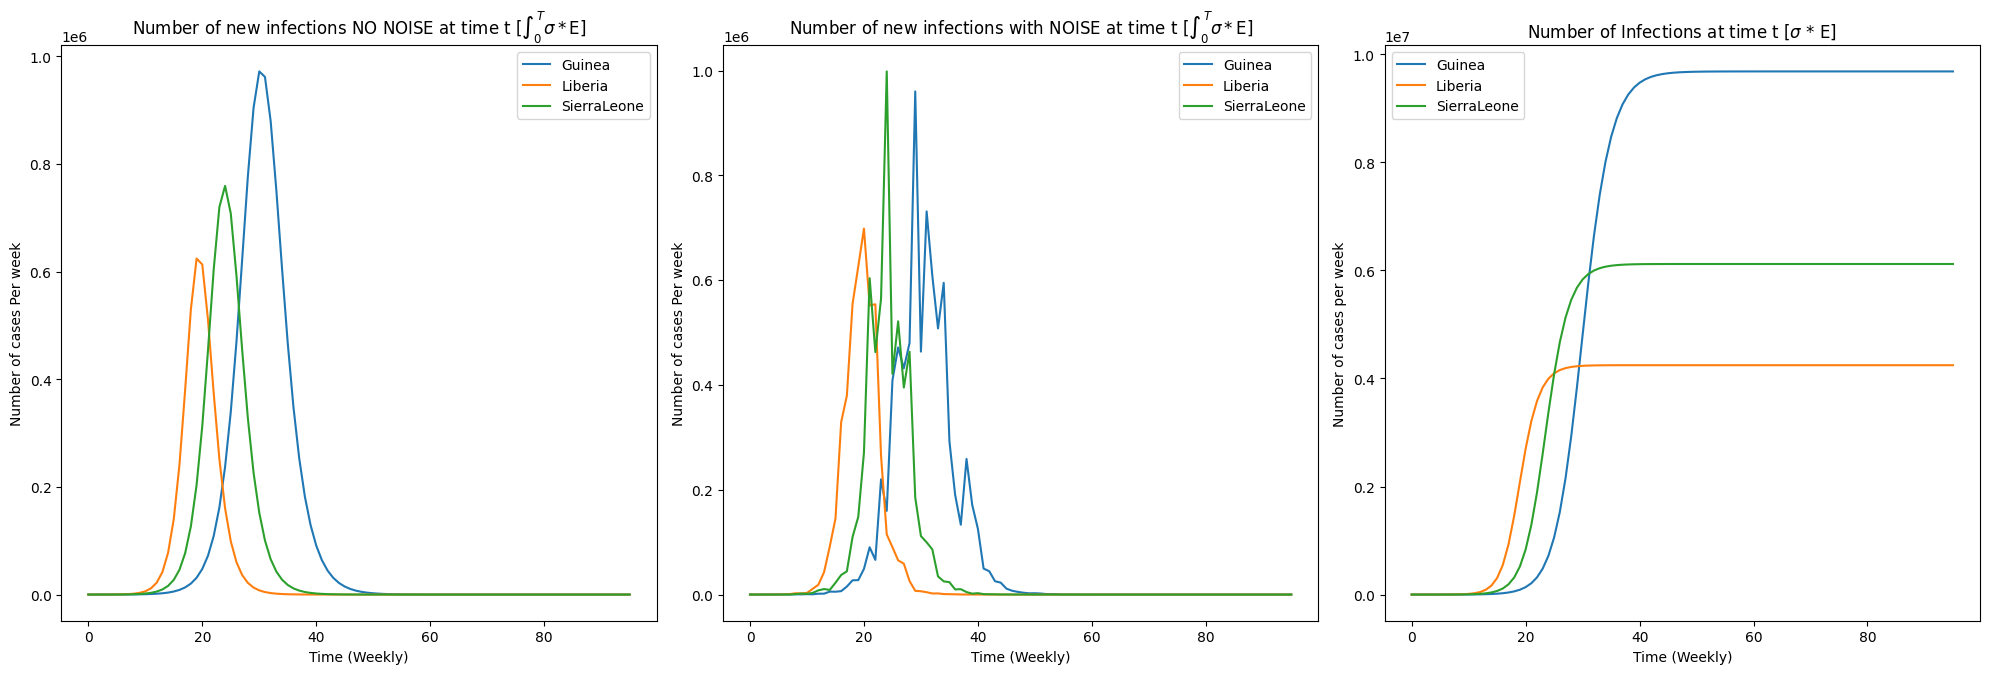

In [13]:
fig, ax = plt.subplots(1,3, figsize = (20,7))
countries = ['Guinea', 'Liberia', 'SierraLeone']
for i in range(3):
    ax[0].plot(raw[f'{countries[i]}_New_case'])
    ax[0].legend(countries)
    ax[0].set_title('Number of new infections NO NOISE at time t $[\int_0^T \sigma*$E]')
    ax[0].set_xlabel('Time (Weekly)')
    ax[0].set_ylabel('Number of cases Per week')

    ax[1].plot(raw[f'{countries[i]}_Noise'])
    ax[1].legend(countries)
    ax[1].set_title('Number of new infections with NOISE at time t $[\int_0^T \sigma*$E]')
    ax[1].set_xlabel('Time (Weekly)')
    ax[1].set_ylabel('Number of cases Per week')

    ax[2].plot(raw[f'C_{countries[i]}'])
    ax[2].legend(countries)
    ax[2].set_title('Number of Infections at time t [$ \sigma$ * E]')
    ax[2].set_xlabel('Time (Weekly)')
    ax[2].set_ylabel('Number of cases per week')

plt.tight_layout()
plt.show()

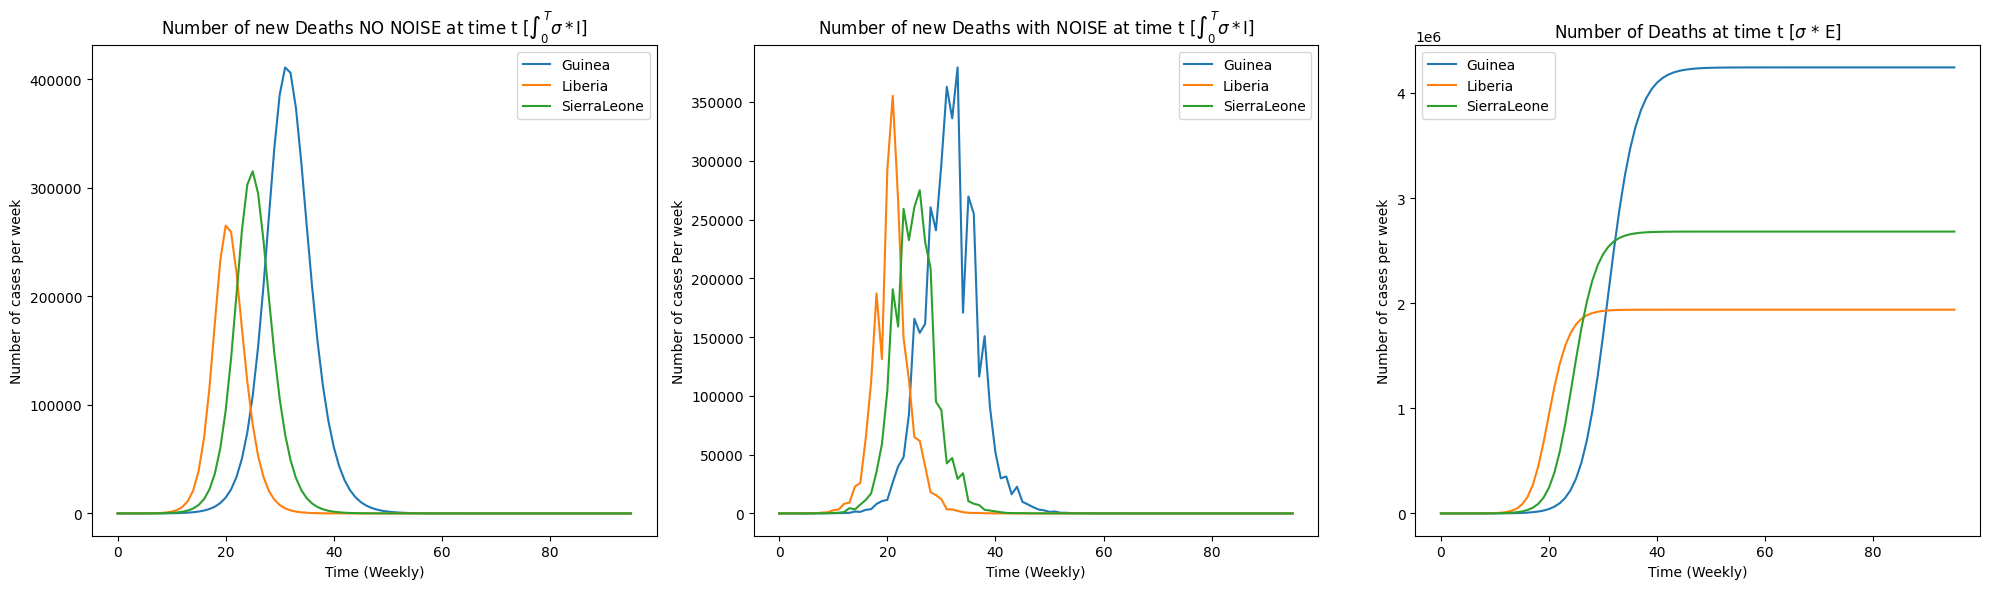

In [14]:
fig, ax = plt.subplots(1,3, figsize = (20,6))
countries = ['Guinea', 'Liberia', 'SierraLeone']
for i in range(3):
    ax[0].plot(raw[f'{countries[i]}_New_Deaths'])
    ax[0].legend(countries)
    ax[0].set_title('Number of new Deaths NO NOISE at time t $[\int_0^T \sigma*$I]')
    ax[0].set_xlabel('Time (Weekly)')
    ax[0].set_ylabel('Number of cases per week')

    ax[1].plot(raw[f'{countries[i]}_Death_Noise'])
    ax[1].legend(countries)
    ax[1].set_title('Number of new Deaths with NOISE at time t $[\int_0^T \sigma*$I]')
    ax[1].set_xlabel('Time (Weekly)')
    ax[1].set_ylabel('Number of cases Per week')

    ax[2].plot(raw[f'D_{countries[i]}'])
    ax[2].legend(countries)
    ax[2].set_title('Number of Deaths at time t [$ \sigma$ * E]')
    ax[2].set_xlabel('Time (Weekly)')
    ax[2].set_ylabel('Number of cases per week')

plt.tight_layout()
plt.show()

In [15]:
# Plot for each country
countries = ['Guinea', 'Liberia', 'SierraLeone']
def plot_SEIR(df, country_name, Death = False, save=False, yscale = True):
    # Extract data for the current country
    S = df[f'S_{country_name}']
    E = df[f'E_{country_name}']
    I = df[f'I_{country_name}']
    R = df[f'R_{country_name}']

    # Create plot
    plt.figure(figsize=(13, 6))
    plt.plot(df['Day'], S, label='Susceptible', color='blue')
    plt.plot(df['Day'], E, label='Exposed', color='orange')
    plt.plot(df['Day'], I, label='Infective', color='red')
    plt.plot(df['Day'], R, label='Recovered', color='green')
    if Death:
        D = df[f'D_{country_name}']
        plt.plot(df['Day'], D, label='Death', color='black')

    # Customize the plot
    plt.xlabel('Day')
    plt.ylabel('Number of Individuals')
    plt.title(f'SEIRD Dynamics for {country_name}')
    plt.legend()
    plt.grid(True)
    if yscale:
        plt.yscale('symlog')  # Use symlog scale to handle large ranges
    if save:
        plt.savefig(f'seird_{country_name.lower()}.png')
    plt.show()

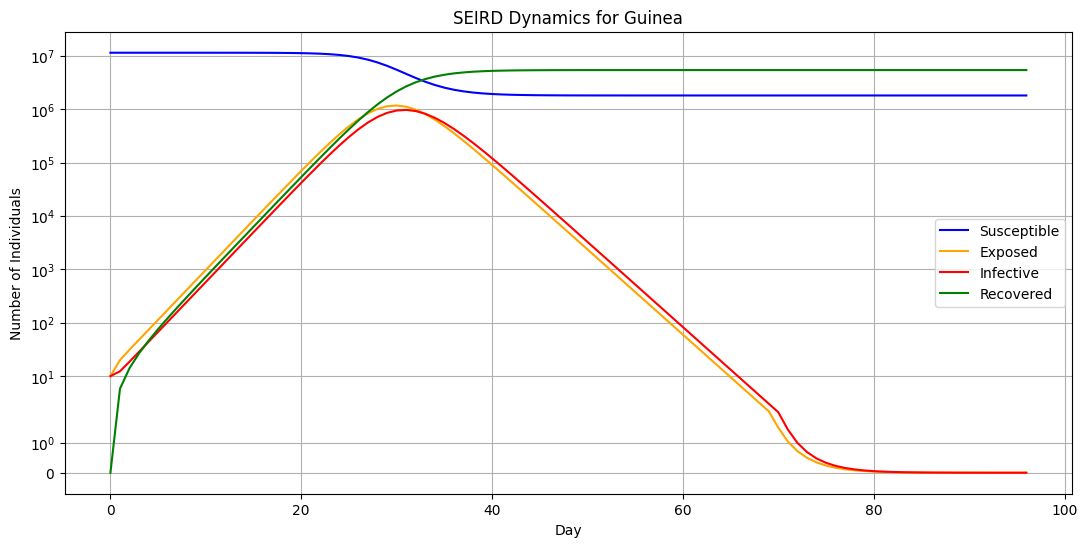

In [16]:
plot_SEIR(raw, 'Guinea')

# Aggregate the Data from daily cases to weekly cases

## Aggregate the Data

In [17]:
# def Aggregate_data(data):
#     # Convert the 'time' column to datetime format, assuming it represents days since 2014-01-01
#     # data["time"] = pd.Timestamp("2014-01-01") + pd.to_timedelta(data["time"], unit="D")

#     ## get patches
#     patch_names = ["Guinea", "Liberia", "Sierra Leone"]
#     n_patches = len(patch_names)

#     ## Set the start date and end of the date
#     start_date =  data["time"].min()
#     end_date = data["time"].max()
#     weeks = pd.date_range(start=start_date, end=end_date, freq="W-MON")
#     T = len(weeks)

#     ## Create an empty array to store observed cases
#     I_obs = np.zeros((T, n_patches))

#     ## Fill the observed cases array with weekly data for each patch
#     for i, country in enumerate(patch_names):
#         country_data = data[data["country"] == country]
#         weekly_cases = country_data.groupby(pd.Grouper(key="time", freq="W-MON"))['cases'].sum()
#         # weekly_cases.index = pd.to_datetime(weekly_cases.index)
#         weekly_cases = weekly_cases.reindex(weeks, fill_value=0)
#         I_obs[:, i] = weekly_cases.values

#     ## Create a DataFrame for plotting
#     time = np.arange(1, T + 1)
#     Cases = pd.DataFrame(I_obs, columns=patch_names)
#     Cases["Time"] = time
#     Cases["Week"] = weeks[:].strftime("%Y-%m-%d")

#     # Melt the DataFrame for easier plotting
#     Cases = Cases.melt(id_vars=["Time", "Week"], var_name="Patches", value_name="Cases")

#     return Cases

In [18]:
# df2 = raw[['time','Guinea_New_case', 'Liberia_New_case', 'SierraLeone_New_case']]
# # weekly_cases = df2.groupby(pd.Grouper(key="time", freq="W-MON"))[['Guinea_New_case', 'Liberia_New_case', 'SierraLeone_New_case']].sum()

## Add the noise to the data

In [19]:
# def add_nb_noise(series, dispersion=10):
#     # Ensure the series contains only numeric values
#     series = pd.to_numeric(series, errors='coerce')  # Convert non-numeric to NaN
#     series = series.fillna(0)  # Replace NaN with 0 (or handle it as needed)

#     mu = series.values
#     r = dispersion
#     p = r / (r + mu)  # NB2 parameterization

#     noisy = np.random.negative_binomial(n=r, p=p)
#     return pd.Series(noisy, index=series.index)


In [20]:
# weekly_cases = weekly_cases.reset_index(drop=True)

# # Apply to all three columns
# noisy_cases = weekly_cases.copy()
# for col in noisy_cases.columns:
#     noisy_cases[col] = add_nb_noise(noisy_cases[col], dispersion=10)

# noisy_cases.head()

## Plot them

In [21]:
# fig, ax = plt.subplots(1, 2, figsize=(18, 7))
# ct =['Guinea_New_case', 'Liberia_New_case', 'SierraLeone_New_case']

# # Plot each patch separately
# for patch in ct:
#     ax[0].plot(raw['Day'], raw[patch], label=patch)
# ax[0].set_title("Weekly New Ebola Cases (Noised Before Aggregation)")
# ax[0].set_xlabel("Week")
# ax[0].set_ylabel("Number of Cases")
# ax[0].legend(title="Patches")

# for patch in ct:
#     ax[1].plot(noisy_cases.index, noisy_cases[patch], label=patch)
# ax[1].set_title("Weekly New Ebola Cases  (Noised After aggregation)")
# ax[1].set_xlabel("Week")
# ax[1].set_ylabel("Number of Cases")
# ax[1].legend(title="Patches")
# # plt.grid(True)
# # plt.savefig('./images/weekly_cases.pdf', bbox_inches='tight')
# plt.show()

# Create a function to plot Posterior for Parameters

In [22]:
import math

def plot_posterior_kde_grid(fit:any, parameters: list, n_cols: int, true_values: dict = None, save:str = None):
    """
    Plot KDEs of posterior samples for given parameters from a CmdStanMCMC fit.

    Args:
        fit (CmdStanMCMC): The fitted model.
        parameters (list of str): Names of parameters to plot.
        n_rows (int): Number of subplot rows.
        n_cols (int): Number of subplot columns.
        true_values (dict, optional): Dict mapping param names to true values for reference lines.
    """
    posterior_samples = fit.draws_pd()
    
    # Dynamically calculate the number of rows
    n_params = len(parameters)
    n_rows = math.ceil(n_params / n_cols)

    fig, ax = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows))
    ax = ax.flatten()  # flatten axes for easy indexing

    for i, param in enumerate(parameters):
        if param in posterior_samples.columns:
            sns.kdeplot(posterior_samples[param], fill=True, ax=ax[i])
            if true_values and param in true_values:
                ax[i].axvline(x=true_values[param], color='r', linestyle='--', label='True value')
                ax[i].legend()
            ax[i].set_xlabel(param)
            ax[i].set_ylabel('Density')
            ax[i].set_title(f'Posterior of {param}')
        else:
            ax[i].text(0.5, 0.5, f"{param} not found", ha='center', va='center')
            ax[i].axis('off')

    # Hide unused axes
    for j in range(len(parameters), len(ax)):
        ax[j].axis('off')

    plt.tight_layout()
    if save:
        plt.savefig(f'./images/{save}.pdf', bbox_inches='tight')
    plt.show()


# Fit the Model to daily cases


In [23]:
# Aggregate cases by country and week
countries = ['Guinea', 'Liberia', 'Sierra Leone']
# weekly_cases = df.groupby(['country', pd.Grouper(key='time', freq='W')]).sum().unstack(fill_value=0).T
weekly_cases1 = raw['Guinea_Noise']
weekly_cases2 = raw['Liberia_Noise']
weekly_cases3 = raw['SierraLeone_Noise']

cases1 = weekly_cases1.values  # Shape: (T, 3)
cases2 = weekly_cases2.values  # Shape: (T, 3)
cases3 = weekly_cases3.values  # Shape: (T, 3)

N = np.array([11.5e6, 4.5e6, 6.8e6]) 
# N = np.array([110000, 440000, 680000]) 
# N=np.array([2e6, 1.5e6, 1e6])
# Set the population size
# N = n[0] #763

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate (R0 = beta/gamma)
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/13, 1/14, 1/13])*7
alpha = np.array([0.06, 0.06, 0.06])*7

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 

# Define initial conditions
i0 = [10, 10, 10]
e0 = [10, 1, 1]
s0 = N - i0
r0 = [0, 0, 0]
c0 = [0, 0, 0]
d0 = [0, 0, 0]
y1 = [s0[0], e0[0], i0[0], r0[0], d0[0], c0[0]]
y2 = [s0[1], e0[1], i0[1], r0[1], d0[1], c0[1]]
y3 = [s0[2], e0[2], i0[2], r0[2], d0[2], c0[2]]


In [24]:

# Make the data struture
seir_data1 = {
    "n_days": len(cases1),
    "y0": y1,
    "t0": 0,
    "t": np.arange(1, len(cases1)+1),
    "N": int(N[0]),
    "cases": cases1,
    'beta_value': beta[0],
    'sigma_value': sigma[0],
    'gamma_value': gamma[0],
    'alpha_value': alpha[0],
    "reporting_rate": reporting_rate
}

seir_data2 = {
    "n_days": len(cases2),
    "y0": y2,
    "t0": 0,
    "t": np.arange(1, len(cases2)+1),
    "N": int(N[1]),
    "cases": cases2,
    'beta_value': beta[1],
    'sigma_value': sigma[1],
    'gamma_value': gamma[1],
    'alpha_value': alpha[1],
    "reporting_rate": reporting_rate
}
seir_data3 = {
    "n_days": len(cases3),
    "y0": y3,
    "t0": 0,
    "t": np.arange(1, len(cases3)+1),
    "N": int(N[2]),
    "cases": cases3,
    'beta_value': beta[2],
    'sigma_value': sigma[2],
    'gamma_value': gamma[2],
    'alpha_value': alpha[2],
    "reporting_rate": reporting_rate
}

seir_incidence_model1 = CmdStanModel(stan_file = 'stan files/guinea.stan')
seir_incidence_model2 = CmdStanModel(stan_file = 'stan files/lib.stan')
seir_incidence_model3 = CmdStanModel(stan_file = 'stan files/sierra.stan')

In [ ]:
fit1 = seir_incidence_model1.sample(data = seir_data1,
                                    #    iter_warmup= 500,
                                    iter_sampling = 1000,
                                    parallel_chains=True,
                                    chains = 4,
                                    seed = 0)

chain 1 |          | 00:00 Status




In [ ]:
fit2 = seir_incidence_model2.sample(data = seir_data2,
                                   iter_sampling = 1000,
                                   parallel_chains=True,
                                   chains = 4,
                                   seed = 2)

chain 1 |          | 00:00 Status




chain 1 |██████████| 09:49 Iteration: 1900 / 2000 [ 95%]  (Sampling)

































































chain 1 |██████████| 2:45:04 Sampling completed                     
chain 2 |██████████| 2:45:04 Sampling completed                     
chain 3 |██████████| 2:45:04 Sampling completed                     
chain 4 |██████████| 2:45:04 Sampling completed                       

In [ ]:
fit3 = seir_incidence_model3.sample(data = seir_data3,
                                   iter_sampling = 1000,
                                   parallel_chains=True,
                                   chains = 4,
                                   seed = 0)

chain 1 |          | 00:00 Status


chain 1 |██████████| 12:56 Iteration: 1900 / 2000 [ 95%]  (Sampling)

































































chain 1 |██████████| 1:54:36 Sampling completed                     
chain 2 |██████████| 1:54:36 Sampling completed                     
chain 3 |██████████| 1:54:36 Sampling completed                       
chain 4 |██████████| 1:54:36 Sampling completed                       

In [ ]:
fit1_summary = fit1.summary()
fit1_summary.filter(items=("sigma", "beta", "gamma", "alpha", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,1.740800,1.267180,1.797640,0.202913,0.531392,0.743291,4.84849,7.13607,2000.0,1.53050
beta,1.583430,0.381662,0.576468,0.372147,0.662176,1.753510,2.30857,7.15803,2000.0,1.54033
gamma,1.180430,0.962363,1.367820,0.230613,0.209594,0.437231,3.53894,7.01290,2000.0,1.55088
alpha,0.811535,0.589567,0.840768,0.192985,0.171552,0.363602,2.25506,7.13430,2000.0,1.53239
recovery_time,2.261810,0.847516,1.535560,1.444480,0.282571,2.287120,4.77114,7.01295,2000.0,1.54951
incubation_period,1.151260,0.391712,0.591405,0.396343,0.206250,1.345370,1.88185,7.13572,2000.0,1.53036
R0,2.048660,0.797745,1.178790,0.606302,0.114298,2.460170,3.41508,7.21907,2000.0,1.53661
phi,4.776850,1.993800,3.093950,2.301990,0.000021,5.555890,8.97085,6.80769,2000.0,1.57842
phi_inv,11755.100000,14377.000000,20362.800000,0.066228,0.111472,0.179989,47030.90000,6.80751,2000.0,1.58133


In [ ]:
fit2_summary = fit2.summary()
fit2_summary.filter(items=("sigma", "beta", "gamma", "alpha", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.937134,0.003520,0.155914,0.134441,0.737102,0.910614,1.226320,2259.81,1850.25,1.00098
beta,2.603140,0.005405,0.252613,0.233628,2.240050,2.572890,3.066540,2247.65,2361.72,1.00075
gamma,0.486848,0.003751,0.158952,0.151825,0.251477,0.472766,0.767828,1918.31,1964.13,1.00223
alpha,0.357717,0.002985,0.140262,0.137101,0.162202,0.339723,0.609731,2222.99,2357.95,1.00223
recovery_time,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incubation_period,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
R0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phi,8.618470,0.045615,2.478250,2.402350,5.087130,8.327320,13.124400,2911.62,2345.26,1.00010
phi_inv,0.126084,0.000731,0.037791,0.034313,0.076194,0.120087,0.196574,2911.62,2345.26,1.00058


In [ ]:
fit3_summary = fit3.summary()
fit3_summary.filter(items=("sigma", "beta", "gamma", "alpha", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,1.108690,0.083041,0.215153,0.298648,0.783828,1.098220,1.393720,17.37500,2000.0,1.15723
beta,1.904680,0.593439,0.887051,0.532365,0.469741,2.193850,2.956830,6.88831,2000.0,1.57034
gamma,1.158140,0.698930,1.005060,0.349871,0.287765,0.657795,2.865500,6.71846,2000.0,1.59621
alpha,0.536548,0.004100,0.179849,0.147336,0.259737,0.567057,0.857889,1331.89000,2000.0,1.53698
recovery_time,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incubation_period,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
R0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phi,7.600210,3.062190,4.759170,3.776350,0.261262,8.799830,14.021400,6.71558,2000.0,1.59364
phi_inv,1.036150,1.137530,1.611270,0.043174,0.071319,0.113639,3.827580,6.71505,2000.0,1.59556


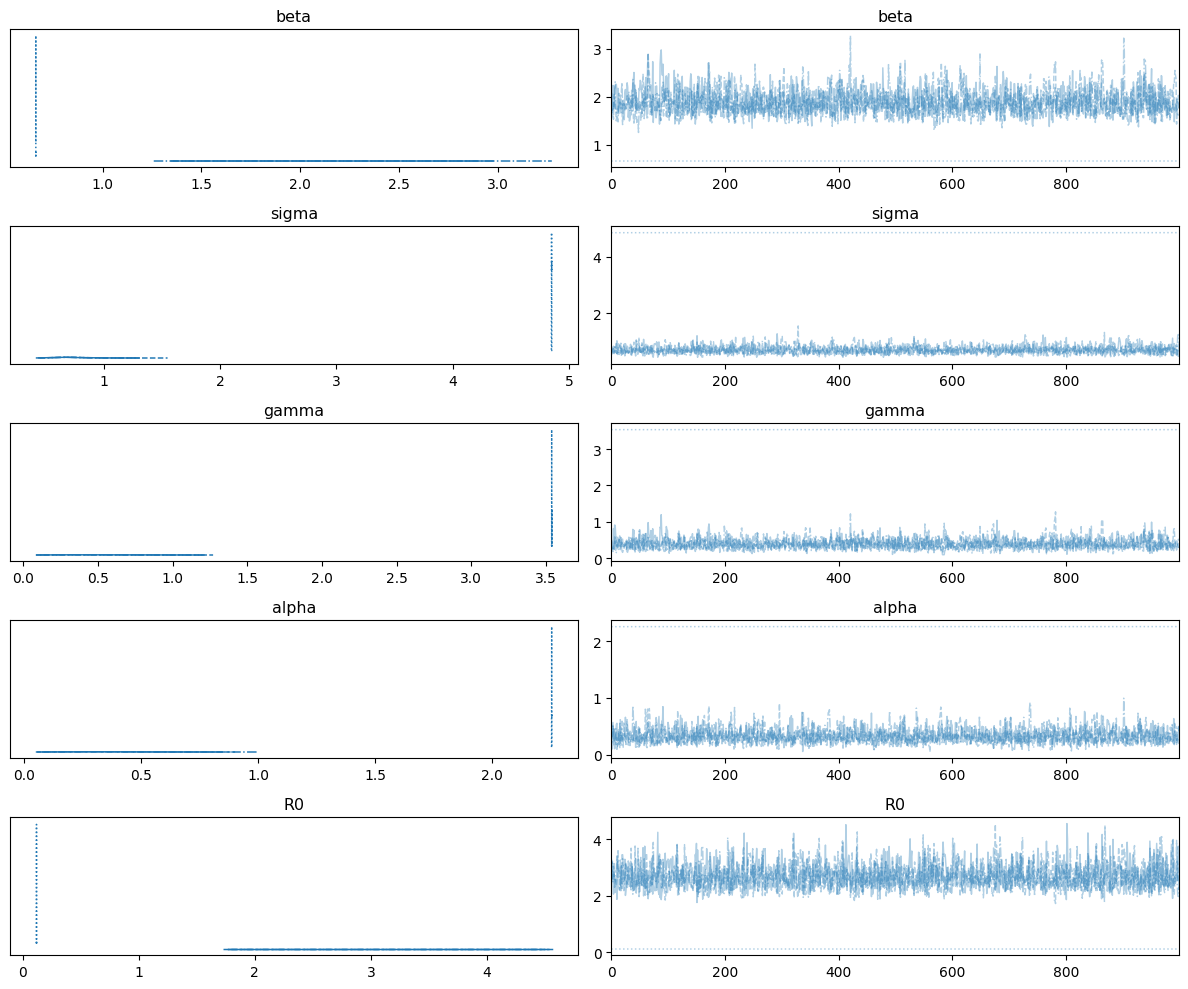

In [ ]:
## trace plots
az.plot_trace(fit1, var_names=["beta", "sigma", "gamma", "alpha", "R0"])
plt.tight_layout()
plt.show()

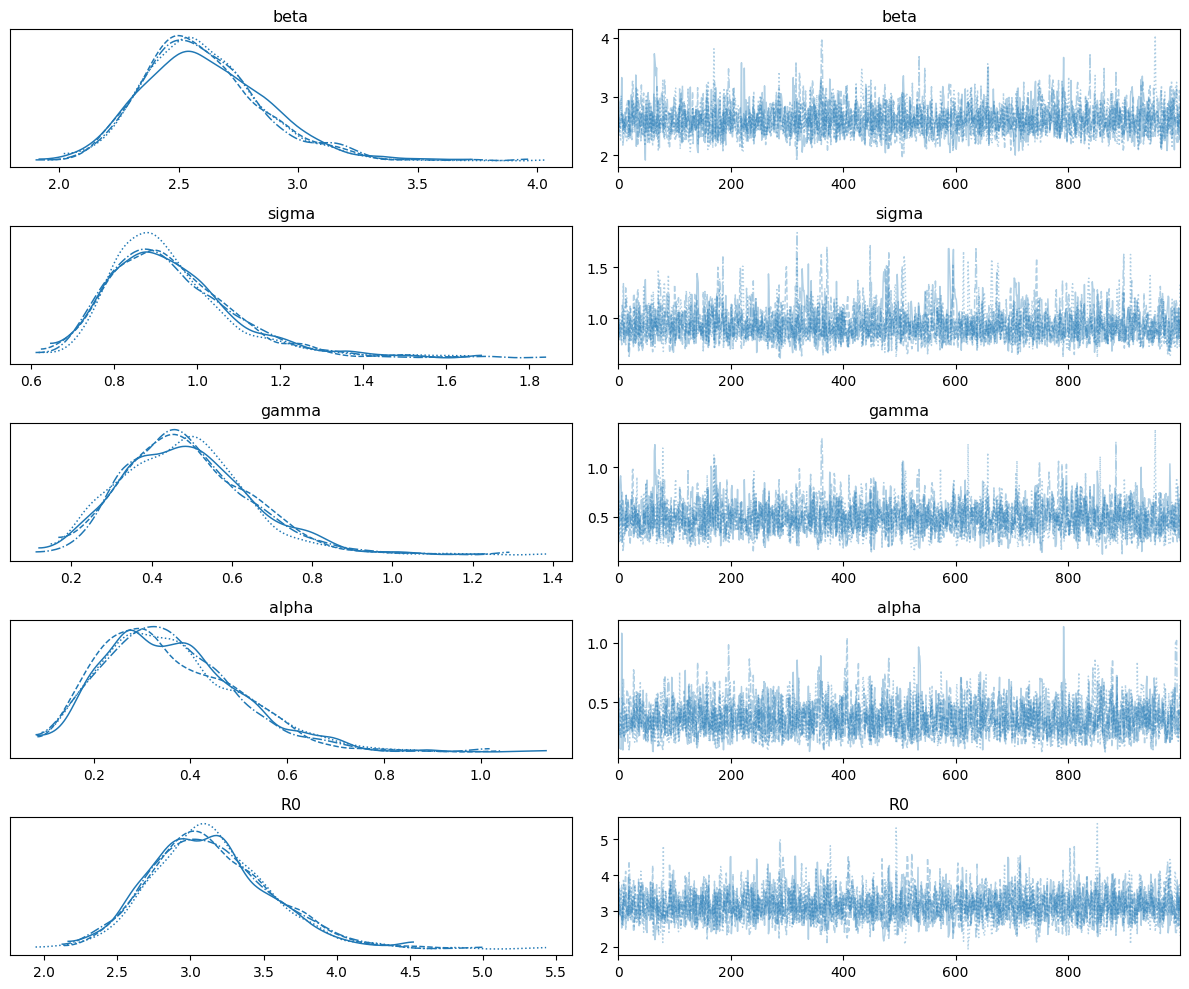

In [ ]:
az.plot_trace(fit2, var_names=["beta", "sigma", "gamma", "alpha", "R0"])
plt.tight_layout()
plt.show()

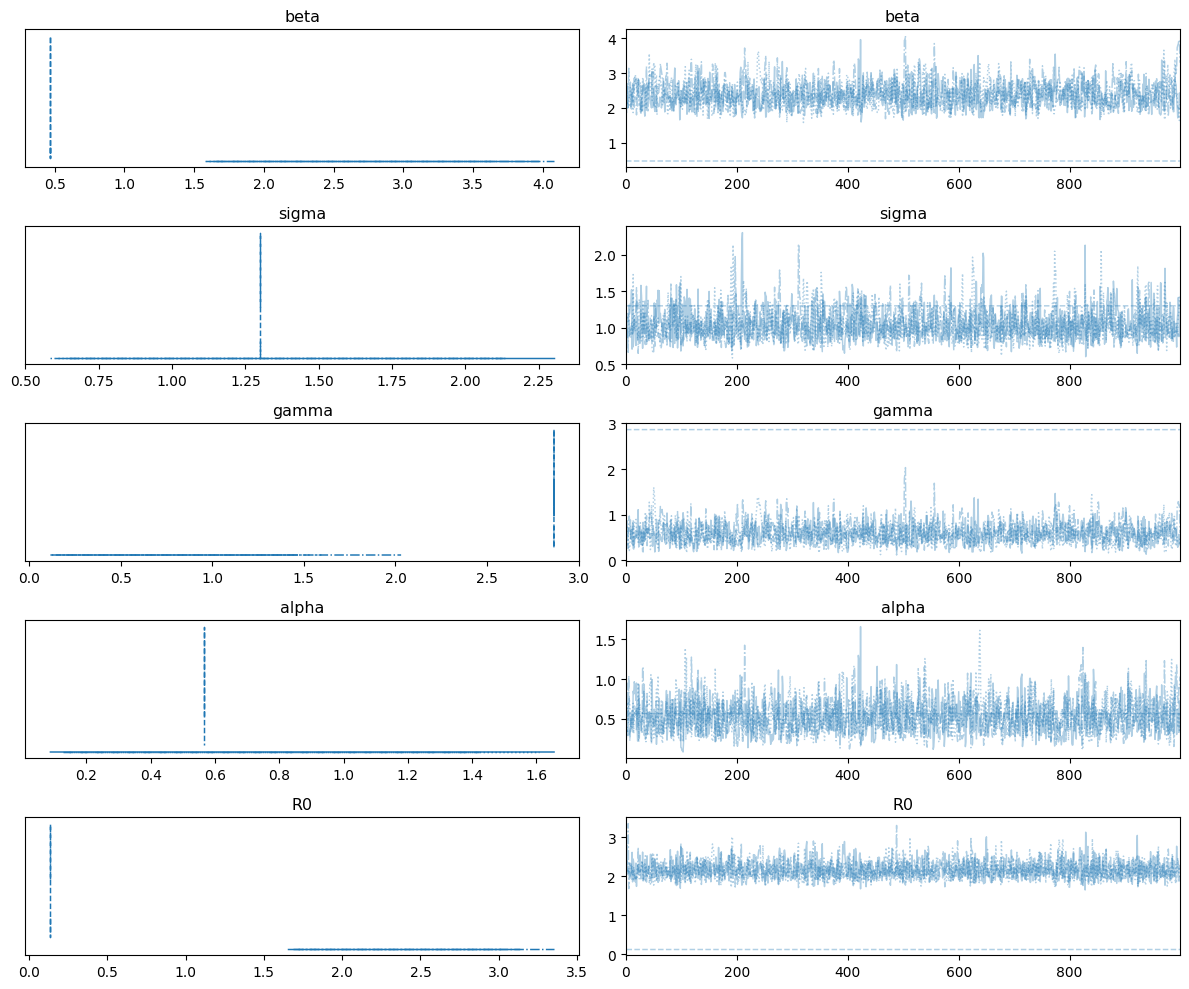

In [ ]:
az.plot_trace(fit3, var_names=["beta", "sigma", "gamma", "alpha", "R0"])
plt.tight_layout()
plt.show()

In [ ]:
# Extract posterior samples
post_guinea = fit1.draws_pd()
post_liberia = fit2.draws_pd()
post_sierra = fit3.draws_pd()

## save the posterior samples
post_guinea.to_csv('./Data/posterior_samples_guinea.csv', index=False)
post_liberia.to_csv('./Data/posterior_samples_liberia.csv', index=False)
post_sierra.to_csv('./Data/posterior_samples_sierra.csv', index=False)

# Posterior Predictive Checks

In [ ]:
fit1_summary.filter(like="pred_incidence", axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
pred_incidence[1],133.3950,125.308,7933.4800,7.4130,0.0,8.0,20.0,NaN,NaN,NaN
pred_incidence[2],13.2368,NaN,10.8805,11.8608,0.0,13.0,32.0,NaN,NaN,NaN
pred_incidence[3],20.6935,NaN,16.2577,17.7912,0.0,21.0,48.0,NaN,NaN,NaN
pred_incidence[4],31.5965,NaN,24.5259,26.6868,0.0,32.0,74.0,NaN,NaN,NaN
pred_incidence[5],48.5115,NaN,36.8384,38.5476,0.0,50.0,110.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
pred_incidence[92],0.0000,NaN,0.0000,0.0000,0.0,0.0,0.0,NaN,NaN,NaN
pred_incidence[93],0.0000,NaN,0.0000,0.0000,0.0,0.0,0.0,NaN,NaN,NaN
pred_incidence[94],0.0000,NaN,0.0000,0.0000,0.0,0.0,0.0,NaN,NaN,NaN
pred_incidence[95],0.0000,NaN,0.0000,0.0000,0.0,0.0,0.0,NaN,NaN,NaN


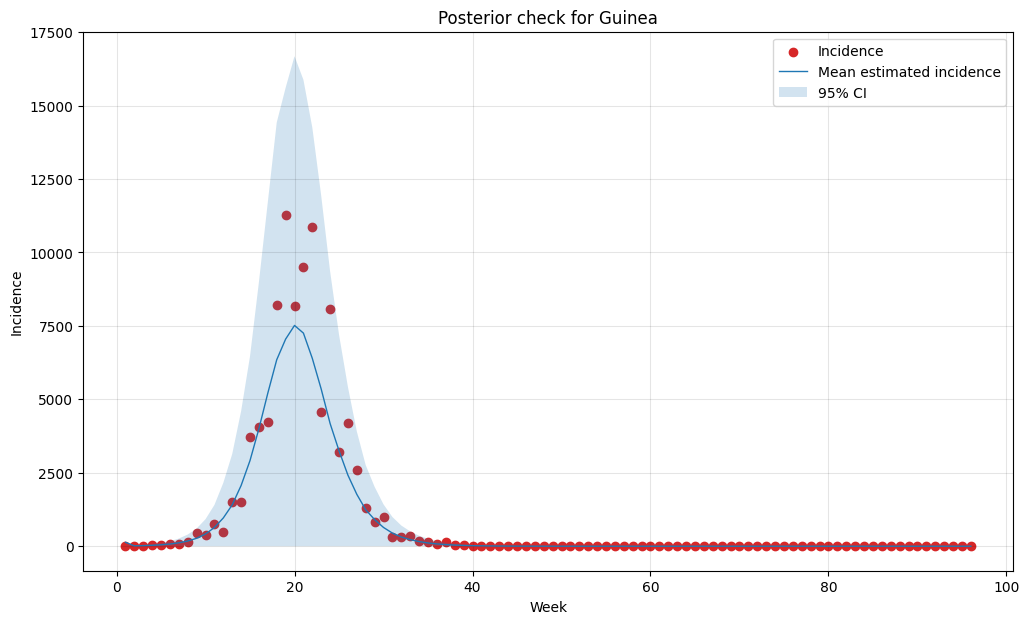

In [ ]:
post_pred1 = pd.DataFrame(fit1_summary.filter(like="pred_incidence", axis=0))
post_pred1["t"] = range(1, T+1)
post_pred1["incidence"] = list(cases1)
post_pred1 = post_pred1.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Guinea')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred1.index, y = post_pred1.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred1.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred1.index, y1 = post_pred1['5%'], y2 = post_pred1['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

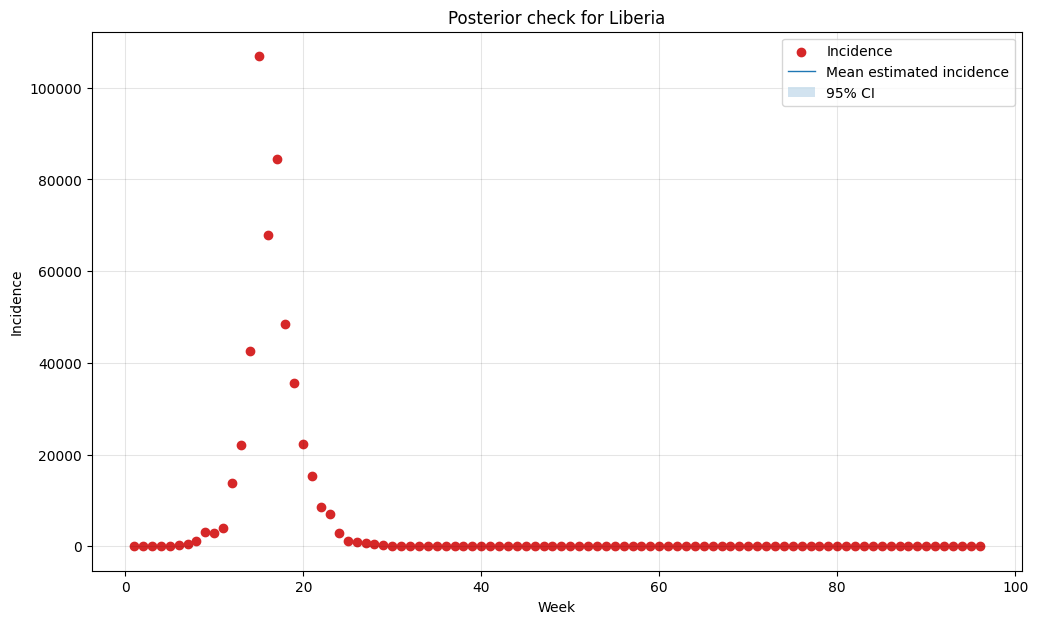

In [ ]:
post_pred2 = pd.DataFrame(fit2_summary.filter(like="pred_incidence", axis=0))
post_pred2["t"] = range(1, T+1)
post_pred2["incidence"] = list(cases2)
post_pred2 = post_pred2.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Liberia')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred2.index, y = post_pred2.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred2.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred2.index, y1 = post_pred2['5%'], y2 = post_pred2['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

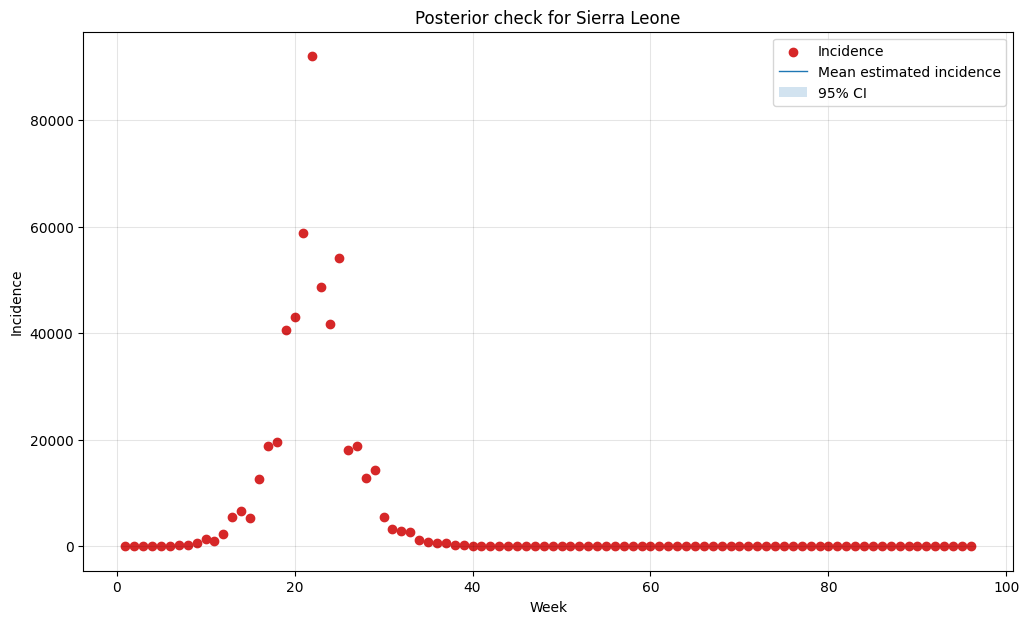

In [ ]:
post_pred3 = pd.DataFrame(fit3_summary.filter(like="pred_incidence", axis=0))
post_pred3["t"] = range(1, T+1)
post_pred3["incidence"] = list(cases3)
post_pred3 = post_pred3.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Sierra Leone')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred3.index, y = post_pred3.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred3.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred3.index, y1 = post_pred3['5%'], y2 = post_pred3['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

In [ ]:
# Assuming `fit` is your CmdStanMCMC object from fitting the model
parameters1 = ["beta", "sigma", "recovery_time", "gamma", "incubation_period", "R0","phi"]

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate (R0 = beta/gamma)
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/13, 1/14, 1/13])*7
alpha = np.array([0.06, 0.05, 0.07])*7

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported
r = beta/(gamma+alpha)
rec = 1.0/gamma
incu = 1.0 / sigma

t1 = {'beta':beta[0],'sigma': sigma[0], 'gamma': gamma[0], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[0], 'recovery_time':rec[0],
    'incubation_period': incu[0]}

t2 = {'beta':beta[1],'sigma': sigma[1], 'gamma': gamma[1], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[1], 'recovery_time':rec[1],
    'incubation_period': incu[1]}

t3 = {'beta':beta[2],'sigma': sigma[2], 'gamma': gamma[2], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[2], 'recovery_time':rec[2],
    'incubation_period': incu[2]}

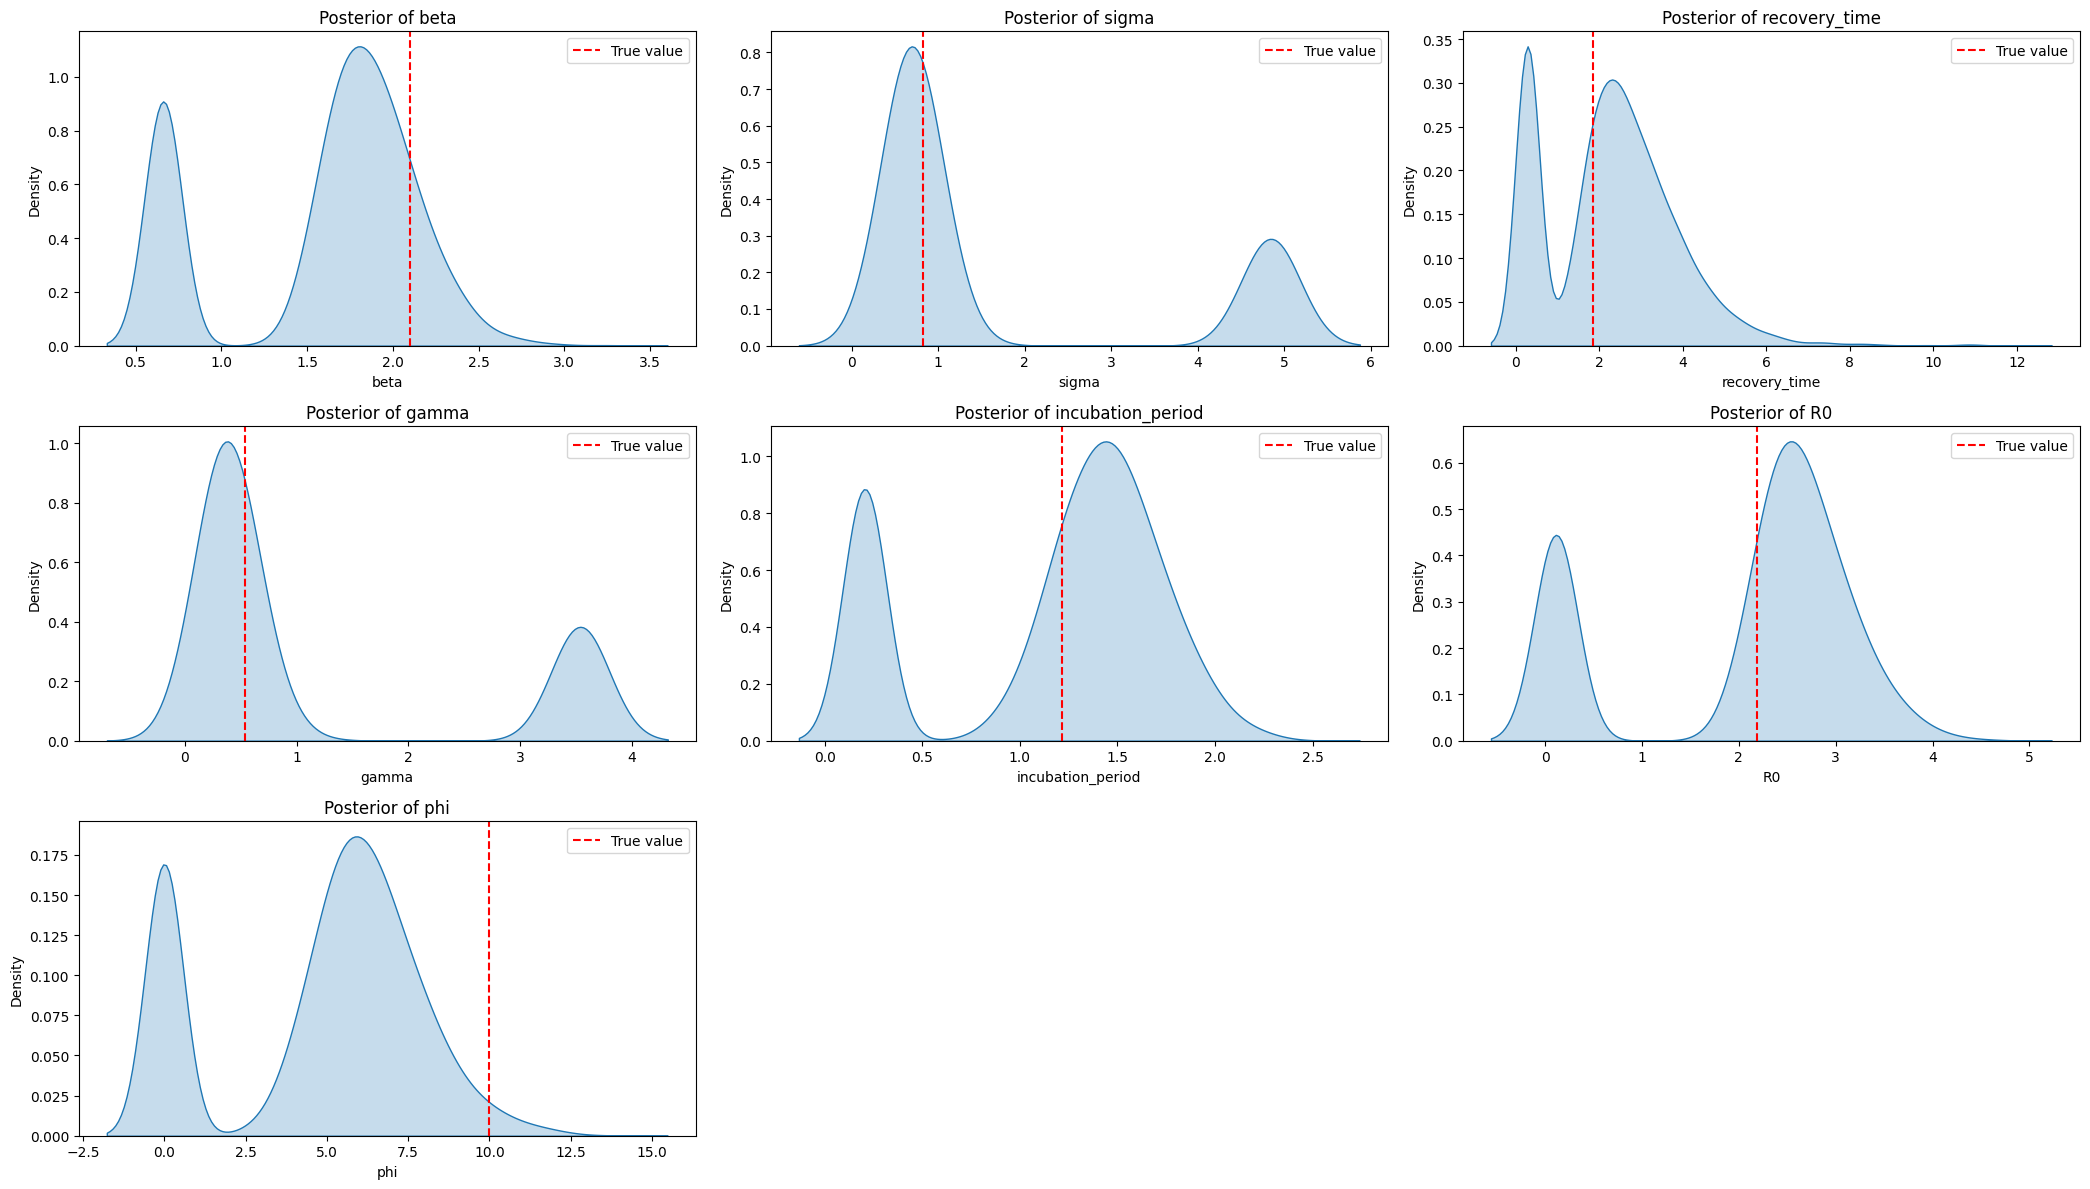

In [ ]:
plot_posterior_kde_grid(fit1, parameters1, 3,t1, save = 'Checks_for_Guinea')

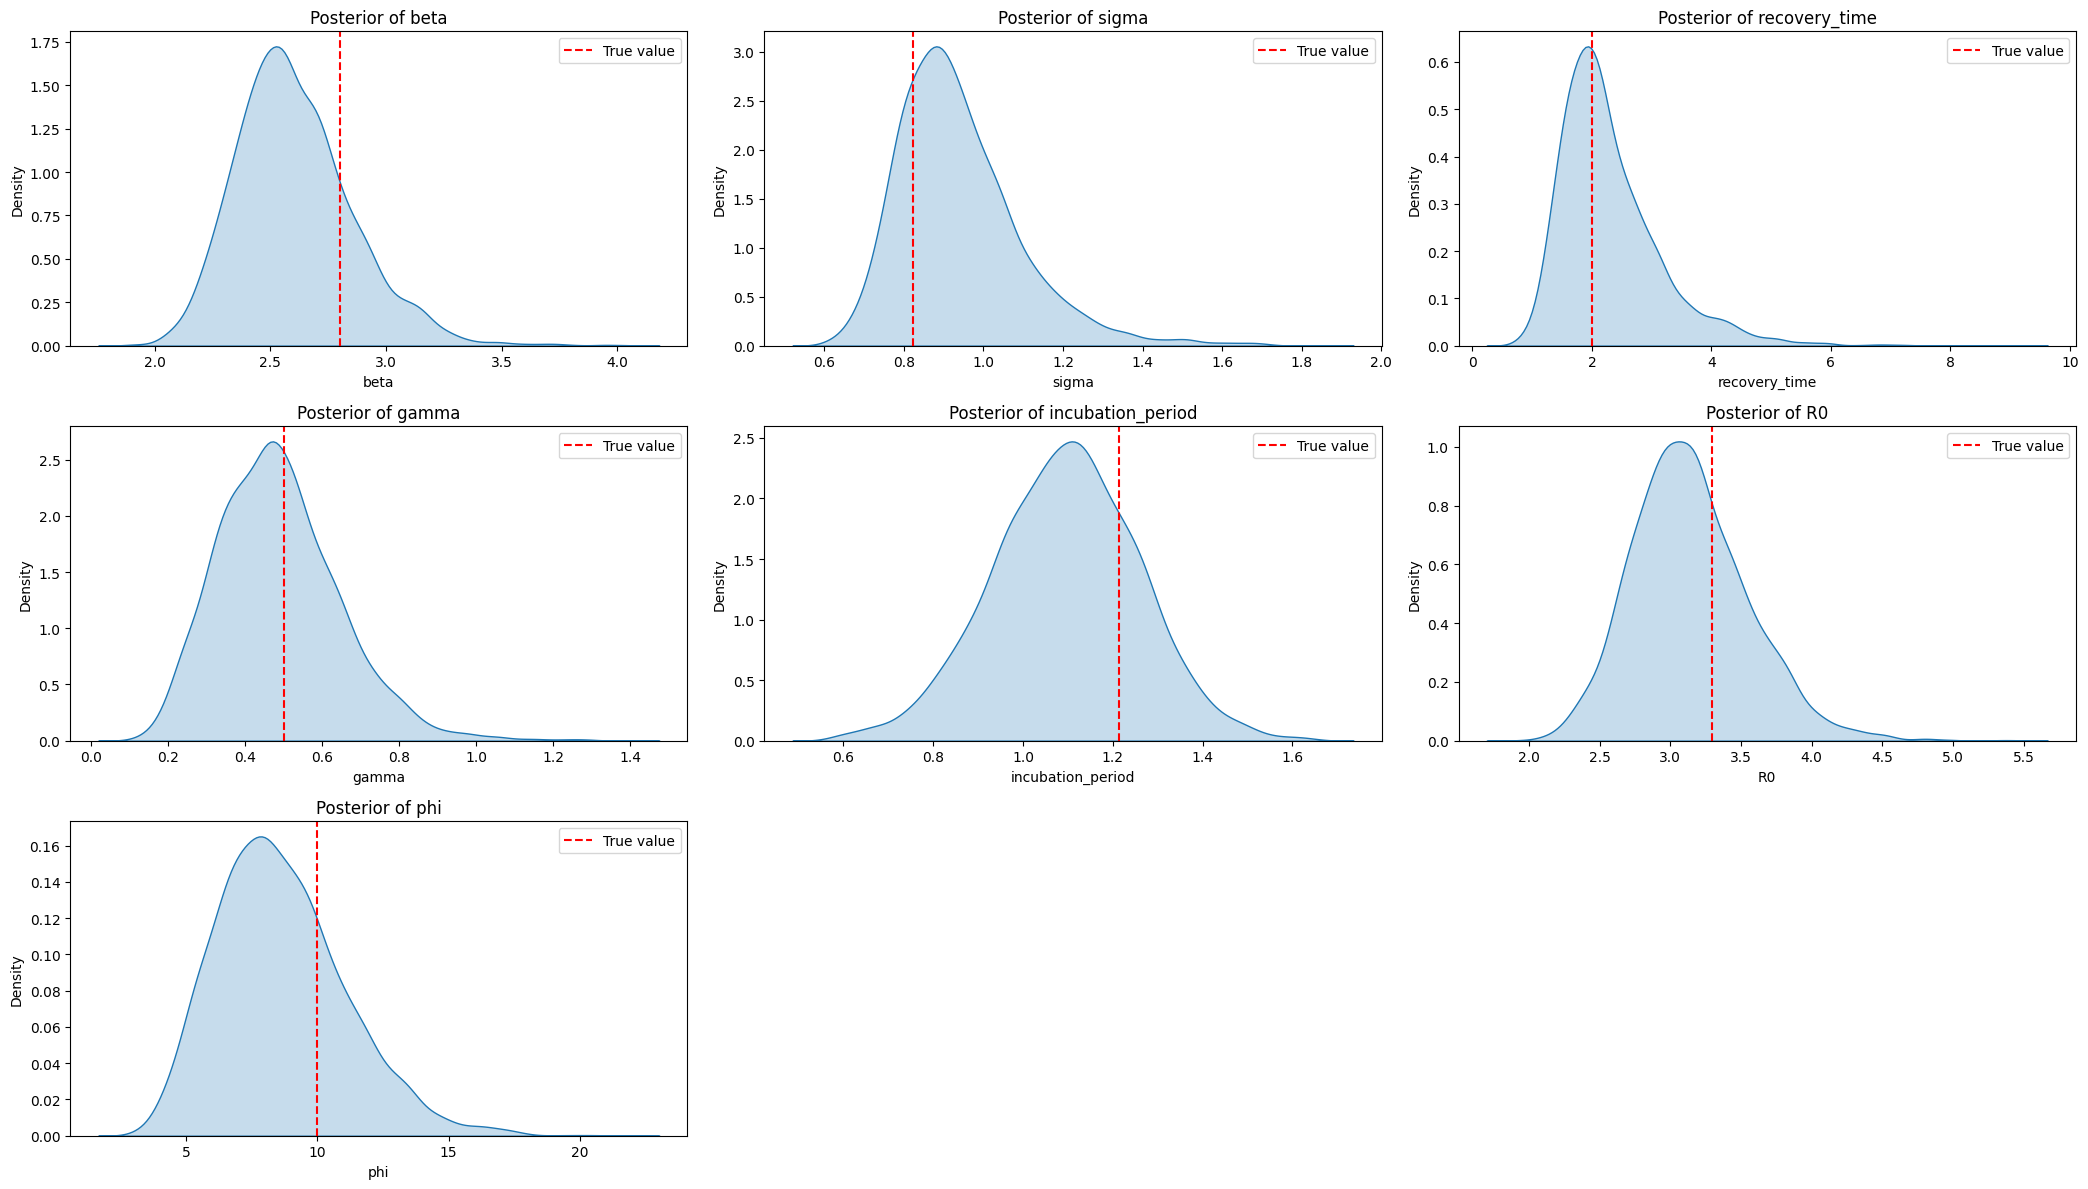

In [ ]:
plot_posterior_kde_grid(fit2, parameters1, 3,t2, save = 'Checks_for_Liberia')

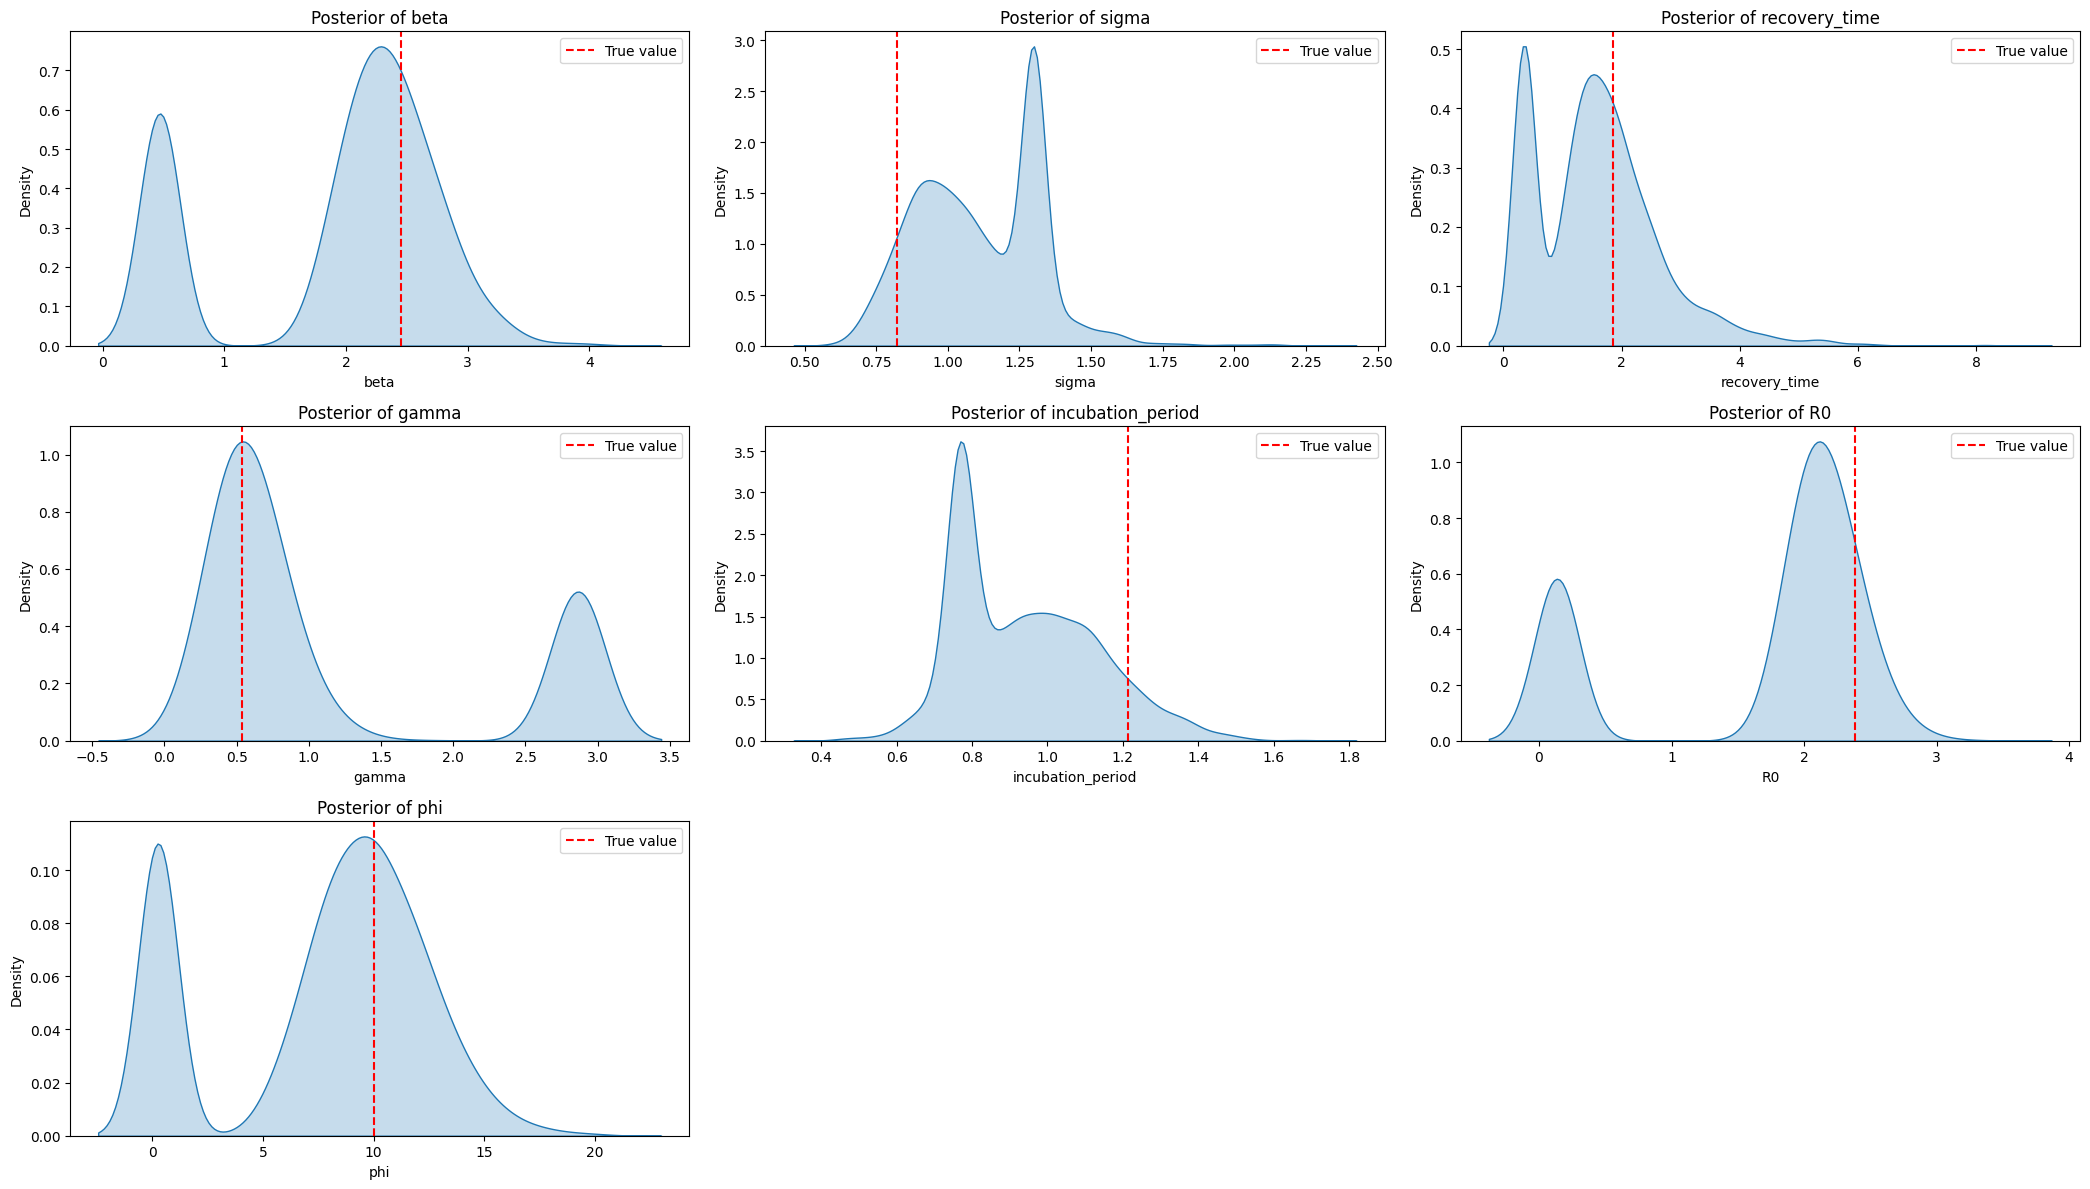

In [ ]:
plot_posterior_kde_grid(fit3, parameters1, 3,t3, save = 'Checks_for_Sierra_Leone')

## Plot SEIR Compartments

In [ ]:

def plot_compartment(fit, country_idx):
    # Time points and countries
    weeks = np.arange(fit.stan_variable('incidence').shape[1])  # Number of weeks
    countries = ['Guinea', 'Liberia', 'Sierra Leone']

    # Plot incidence (infectious) and reconstructed other compartments
    # for i in range(countries):
    # Create figure
    plt.figure(figsize=(12, 7))
    incidence = np.mean(fit.stan_variable('incidence'), axis=0)

    # Reconstruct approximate compartments (scaled by reporting rate)
    I = incidence
    R = np.cumsum(I) * np.mean(fit.stan_variable('gamma'))
    E = np.roll(I, 1) / np.mean(fit.stan_variable('sigma'))  # Exposed ~ delayed infectious
    # E[0] = 0
    S = N[country_idx] - E - I - R

    # Convert to fractions
    S_frac = S / N[country_idx]
    E_frac = E / N[country_idx]
    I_frac = I / N[country_idx]
    R_frac = R / N[country_idx]

    # Plot
    plt.plot(weeks, S_frac, 'b', label='Susceptible')
    plt.plot(weeks, E_frac, 'y', label='Exposed')
    plt.plot(weeks, I_frac, 'r', label='Infectious')
    plt.plot(weeks, R_frac, 'g', label='Recovered')

    # Formatting
    plt.title(f'{countries[country_idx]} (R0={np.mean(fit.stan_variable("R0")):.2f})')
    plt.ylabel('Fraction of Population')
    plt.grid(True, alpha=0.3)
    # ax.set_ylim(0, 1)

    plt.legend(loc='upper right')
    plt.xlabel('Weeks since outbreak start')
    # plt.tight_layout()
    plt.show()                                                                                      

In [ ]:
# plot_compartment(fit_seir_incidence_model, country_idx=0)
# plot_compartment(fit2, country_idx=1)
# plot_compartment(fit3, country_idx=2)

# FITTING FOR 3 PATCHES

In [ ]:
weekly = raw[['Guinea_Noise', 'Liberia_Noise', 'SierraLeone_Noise']]
weekly.head()

,Guinea_Noise,Liberia_Noise,SierraLeone_Noise
0,0,0,0
1,8,17,18
2,17,40,52
3,48,56,34
4,45,107,63


In [ ]:

N = np.array([11.5e6, 4.5e6, 6.8e6]) 
# N = np.array([2e6, 1.5e6, 1e6])
# N = np.array([110000, 440000, 680000])
# Set the population size

# Define initial conditions
g0 = [N[0]-10, 10, 10, 0, 0, 0]
l0 = [N[1]-10, 10, 10, 0, 0, 0]
s0 = [N[2]-10, 10, 10, 0, 0, 0]

ts = weekly.values.T
y0 = [g0, l0, s0]

beta = np.array([0.3, 0.4, 0.35])*7
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/13, 1/14, 1/13])*7
alpha = np.array([0.06, 0.06, 0.06])*7

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1  

# Make the data struture
seir_data = {
    'N_countries': 3,
    "n_weeks": len(ts[0]),
    'y0': y0,
    't0': 0,
    "t": np.arange(1, len(ts[0])+1),
    "N": N.astype(int),
    "cases": ts,
    'beta_values': beta,
    'sigma_values': sigma,
    'gamma_values': gamma,
    'alpha_values': alpha,
    'reporting_rate': reporting_rate
}

multi_model = CmdStanModel(stan_file = 'stan files/mult.stan')

In [ ]:
fit_multi_model = multi_model.sample(data = seir_data,
                                     iter_sampling = 1000,
                                     parallel_chains=True,
                                     chains = 4,
                                     seed = 0)

chain 1 |          | 00:00 Status


chain 1 |██████████| 42:43 Iteration: 1900 / 2000 [ 95%]  (Sampling)

































































chain 1 |██████████| 2:33:53 Sampling completed                     
chain 2 |██████████| 2:33:53 Sampling completed                       
chain 3 |██████████| 2:33:53 Sampling completed                       
chain 4 |██████████| 2:33:53 Sampling completed                       

In [ ]:
print(fit_multi_model.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [ ]:
multy_fit_summary = fit_multi_model.summary()
multy_fit_summary.filter(items=("beta[1]","beta[2]", "beta[3]", "sigma", "recovery_time",
                                 "gamma", "incubation_period", "R0[1]","R0[2]", "R0[3]",
                                   "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
beta[1],1.885630,0.004056,0.250185,0.246771,1.526210,1.855620,2.332290,4148.72,2508.59,1.00024
beta[2],2.576200,0.003592,0.225291,0.212983,2.242040,2.556660,2.976690,4241.10,3084.23,1.00392
beta[3],2.223900,0.004070,0.247477,0.239195,1.874870,2.197870,2.669390,4078.88,2577.14,1.00219
R0[1],2.689930,0.006674,0.432196,0.415002,2.088880,2.633940,3.469550,4347.45,3106.04,1.00053
R0[2],3.169770,0.006522,0.431935,0.410428,2.552460,3.131120,3.940630,4620.08,2900.41,1.00035
R0[3],2.347150,0.004116,0.283593,0.277884,1.944400,2.314890,2.861190,4879.20,2645.88,1.00203
phi,6.234070,0.013313,0.959251,0.951125,4.760100,6.185530,7.918790,5360.60,3023.43,1.00083
phi_inv,0.164252,0.000356,0.025544,0.024791,0.126282,0.161668,0.210079,5360.40,3023.43,1.00064


In [ ]:
# Extract posterior samples
post_no = fit_multi_model.draws_pd()

## save the posterior samples
post_no.to_csv('./Data/posterior_samples_no_coupling.csv', index=False)

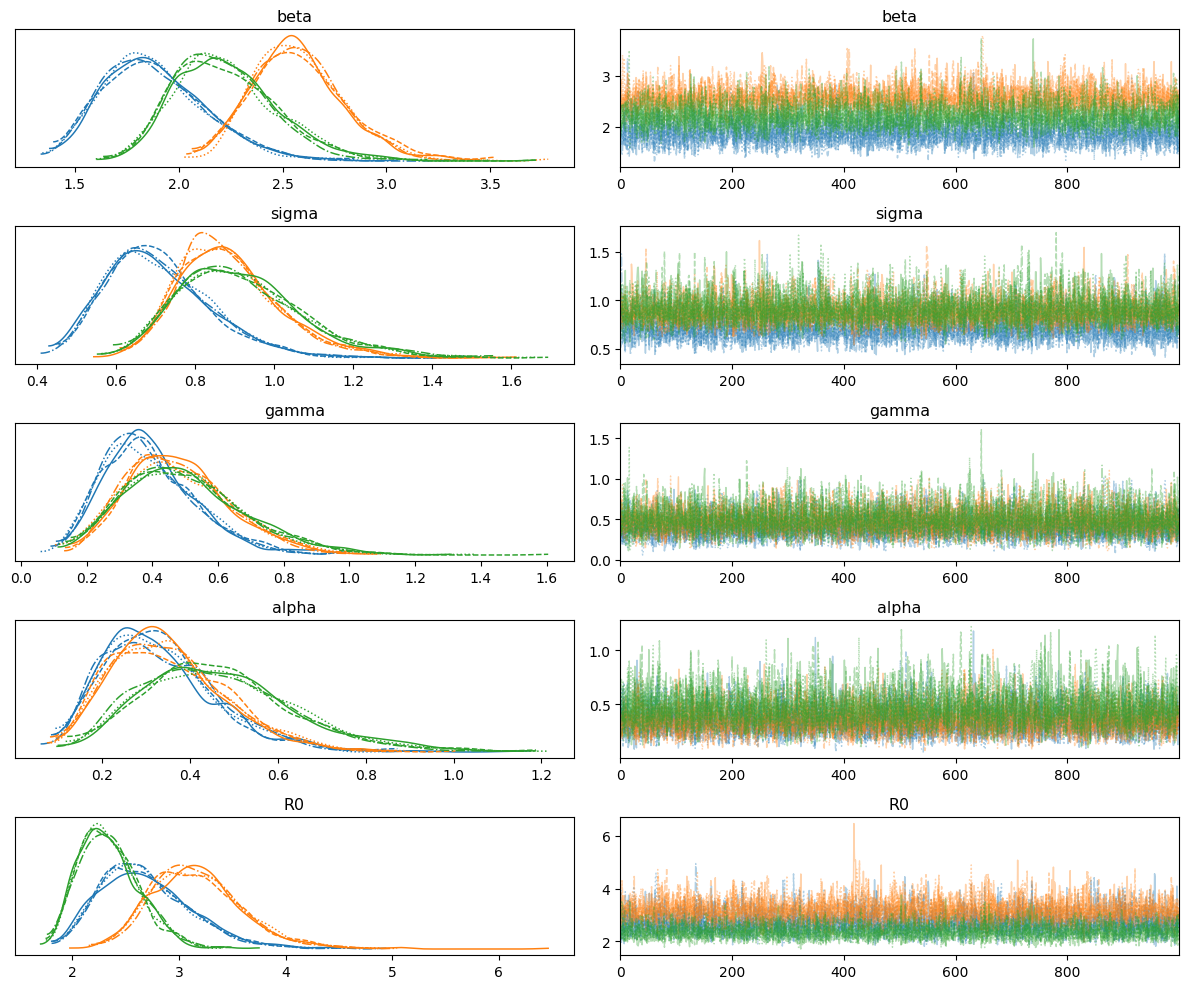

In [ ]:

az.plot_trace(fit_multi_model, var_names=["beta", "sigma", "gamma", "alpha", "R0"])
plt.tight_layout()
plt.show()

# POSTERIOR PREDICTIVE CHECK

In [ ]:
# Get available variables
# Assuming `fit` is your CmdStanMCMC object from fitting the model
posterior_samples = fit_multi_model.draws_pd()  # returns a pandas DataFrame

beta = np.array([0.3, 0.4, 0.3])*7
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/13, 1/14, 1/13])*7   # 1/infectious period (Ebola: ~7 days)
alpha = np.array([0.05, 0.05, 0.05])*7

phi = 10            # Negative binomial dispersion parameter
reporting_rate = 1
r = (beta/(gamma+alpha))
rec = (1.0/gamma)
incu = (1.0 / sigma)

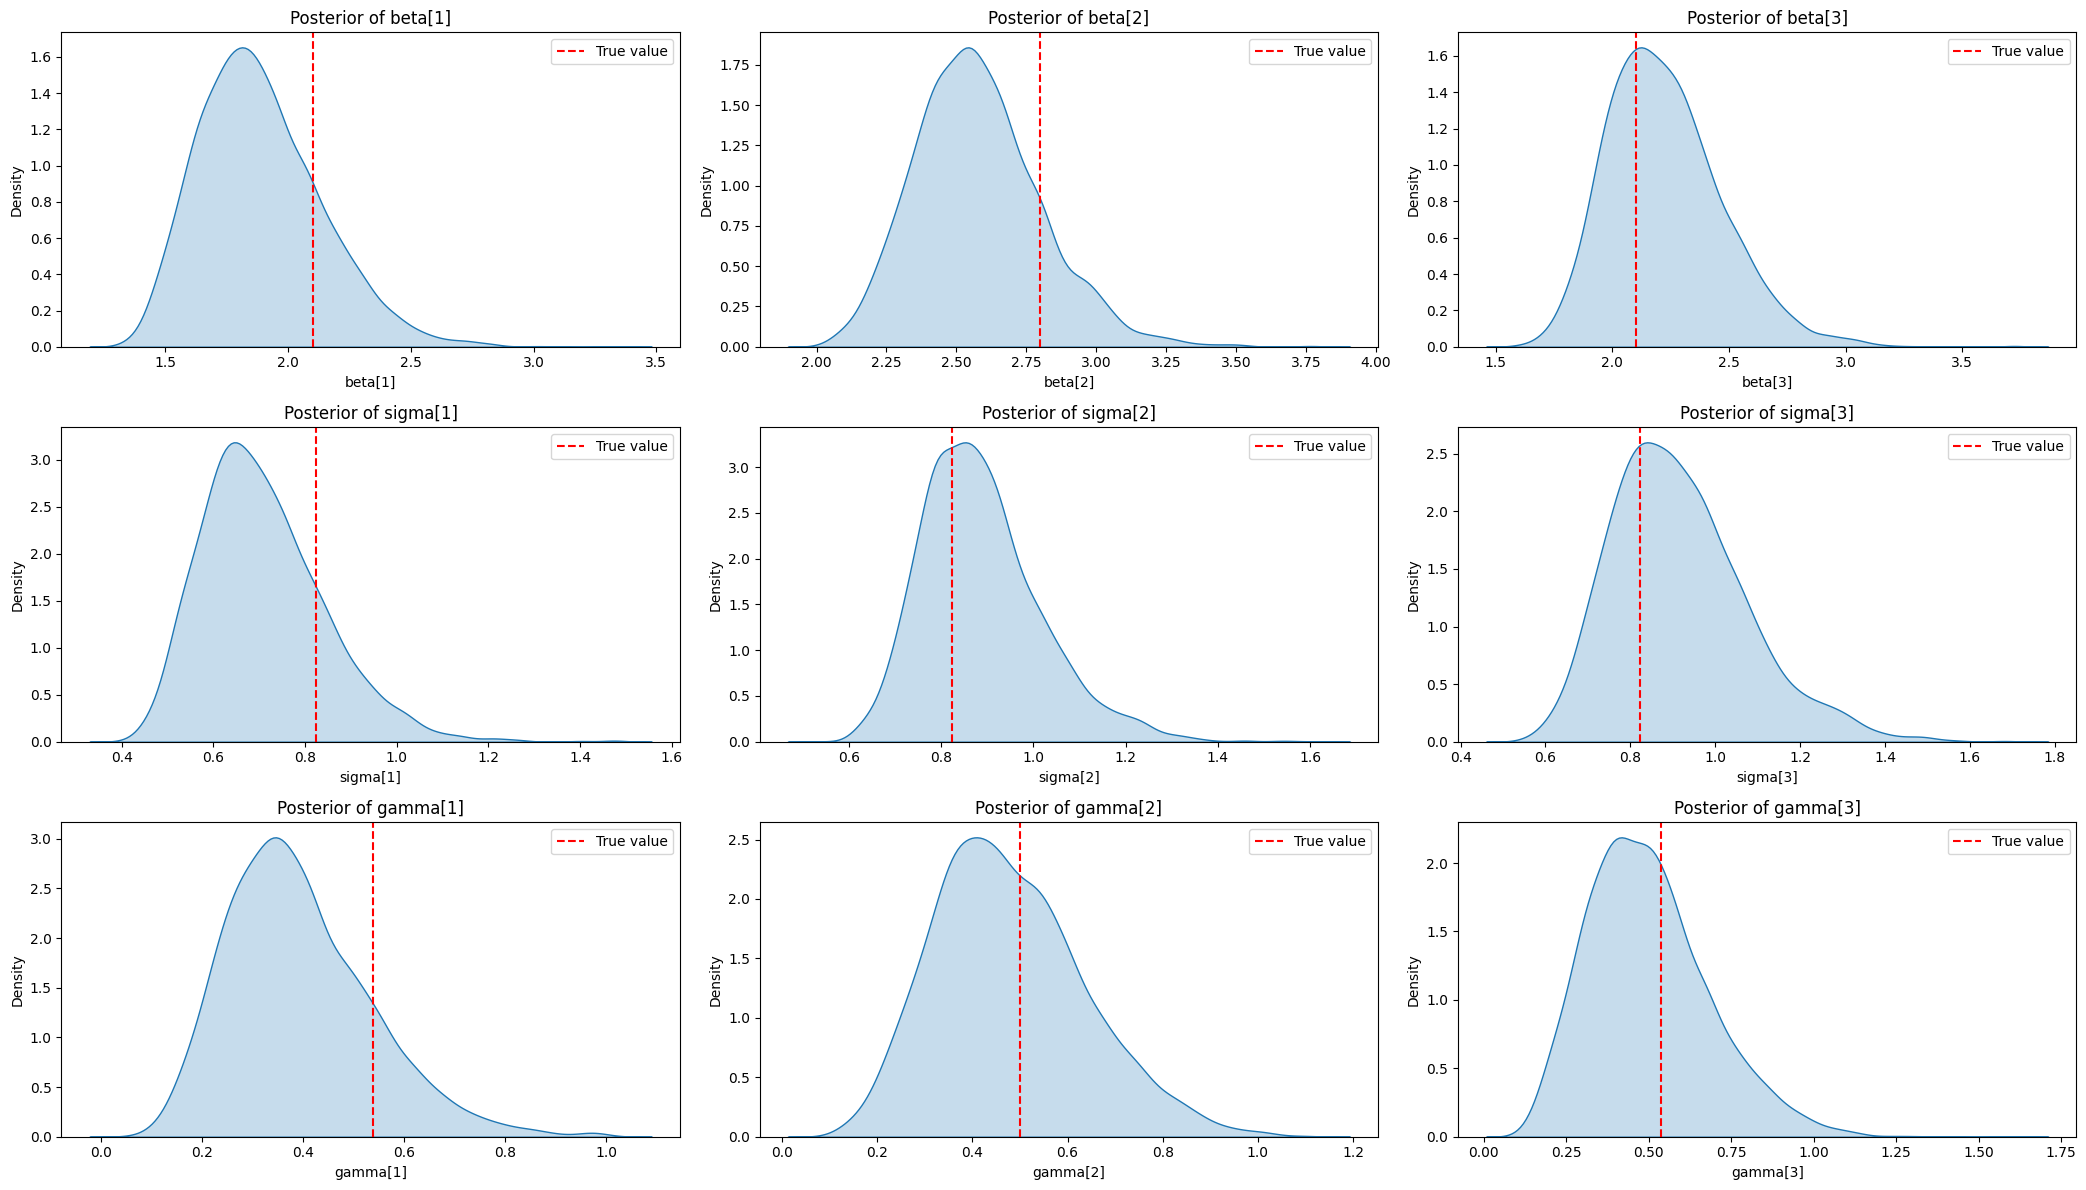

In [ ]:
parameters = ["beta[1]","beta[2]", "beta[3]", 
                "sigma[1]","sigma[2]","sigma[3]", 
                "gamma[1]","gamma[2]","gamma[3]"]
                
t = {'beta[1]': beta[0], 'beta[2]': beta[1], 'beta[3]': beta[2],
    'sigma[1]': sigma[0], 'sigma[2]': sigma[1], 'sigma[3]': sigma[2],   
    'gamma[1]': gamma[0], 'gamma[2]': gamma[1], 'gamma[3]': gamma[2],
    'phi': phi , 'reporting_rate':1}

plot_posterior_kde_grid(fit_multi_model, parameters=parameters, n_cols=3, true_values=t, save = 'Checks_for_betaGammaSigma')

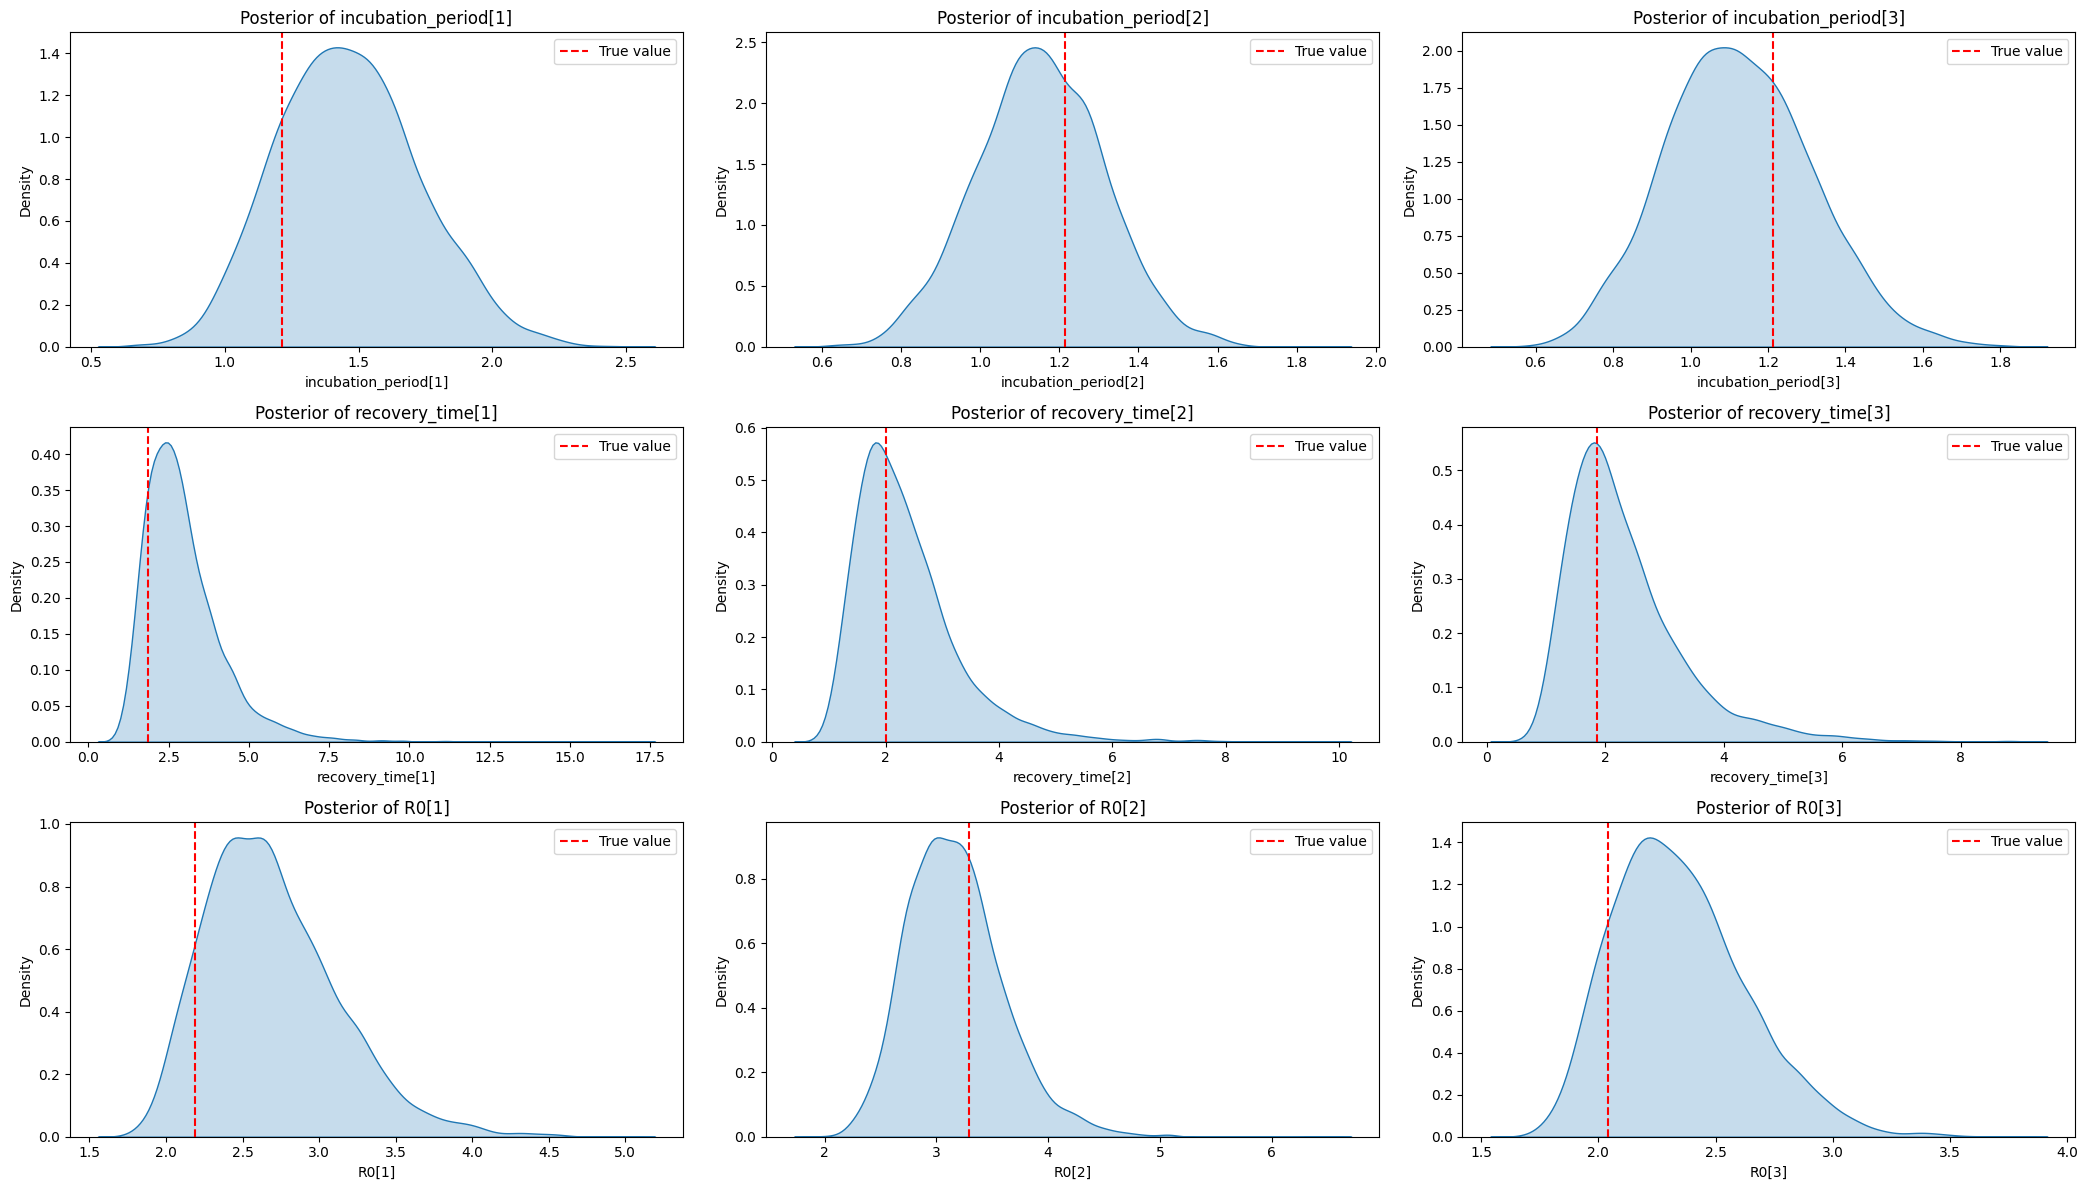

In [ ]:
parameters1 = ["incubation_period[1]","incubation_period[2]","incubation_period[3]", 
                "recovery_time[1]","recovery_time[2]","recovery_time[3]",
                "R0[1]","R0[2]", "R0[3]"]
t1 = {
    'R0[1]': r[0], 'R0[2]': r[1], 'R0[3]': r[2], 
    'recovery_time[1]':rec[0],
    'recovery_time[2]':rec[1],
    'recovery_time[3]':rec[2],
    'incubation_period[1]': incu[0],
    'incubation_period[2]': incu[1],
    'incubation_period[3]': incu[2]}


plot_posterior_kde_grid(fit_multi_model, parameters=parameters1, 
                        n_cols=3, true_values=t1, save = 'Checks_for_recoveryIncubationR0')

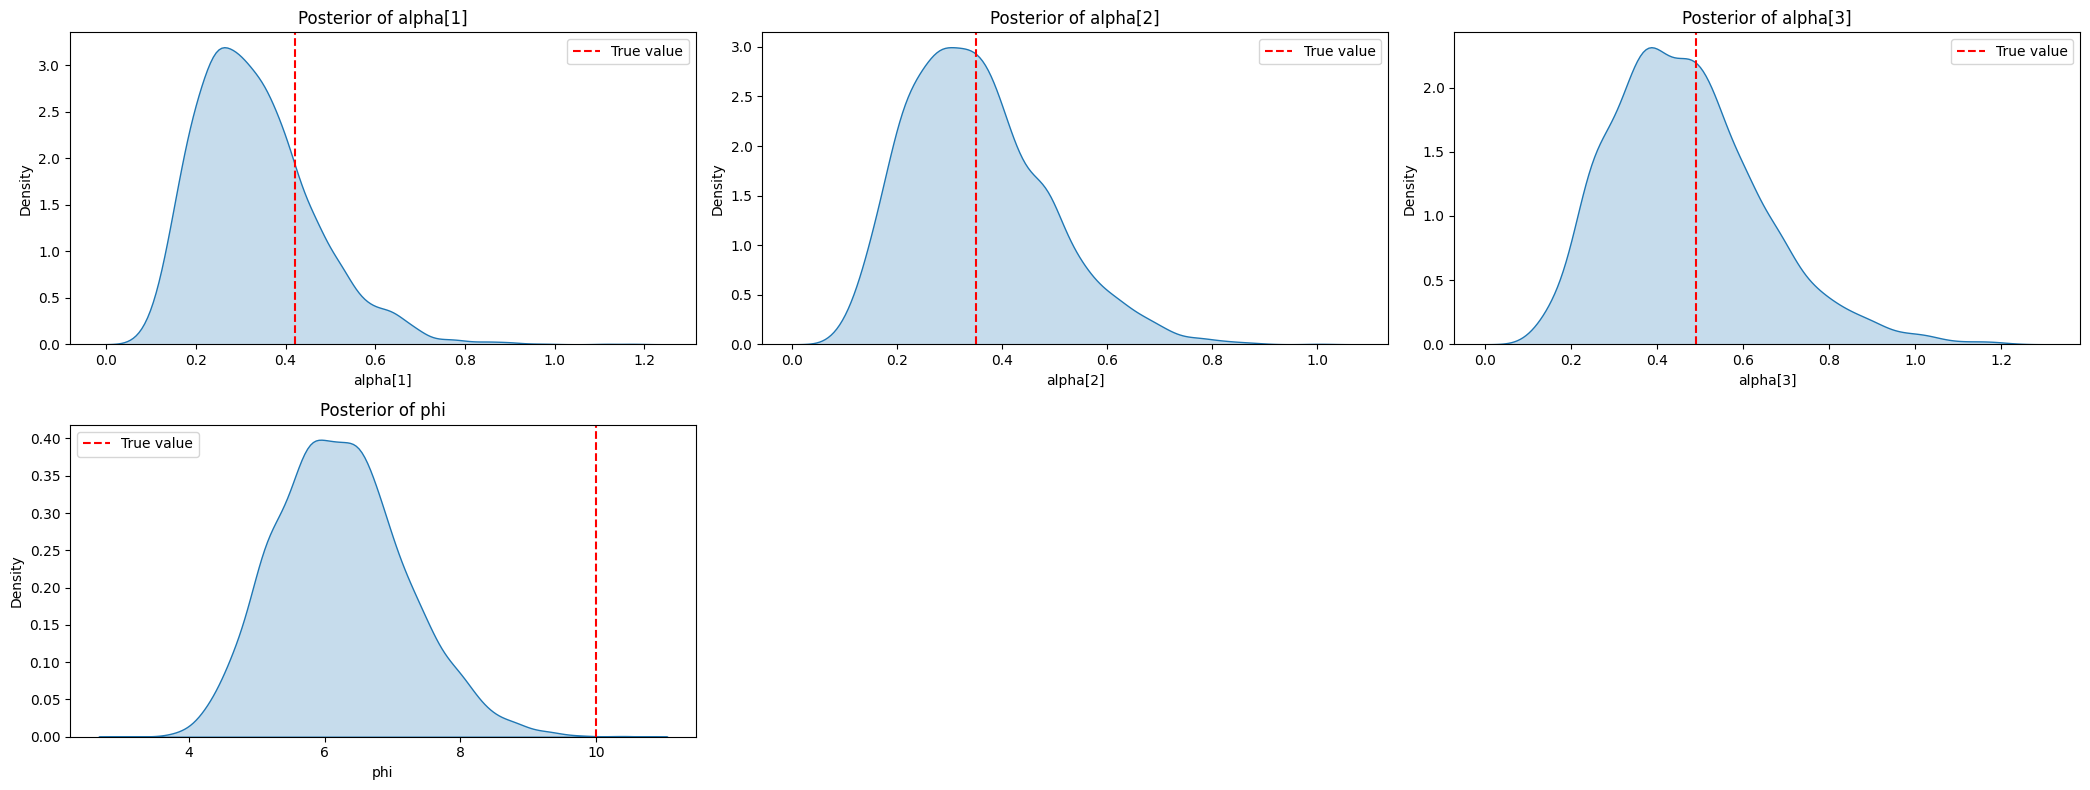

In [ ]:
parameters1 = ['alpha[1]', 'alpha[2]', 'alpha[3]',
               'phi']
t1 = {
    'alpha[1]':alpha[0],
    'alpha[2]':alpha[1],
    'alpha[3]':alpha[2],
    'phi': phi}


plot_posterior_kde_grid(fit_multi_model, parameters=parameters1, 
                        n_cols=3, true_values=t1, save = 'Checks_for_alphaPhi')

# PRIOR PREDICTIVE CHECK

In [ ]:

model_prior = CmdStanModel(stan_file = 'stan files/multi_patch_PRIOR.stan')
prior_check = model_prior.sample(data = seir_data,
                                     iter_sampling = 1000,
                                     chains = 4,
                                     seed = 0)

chain 1 |          | 00:00 Status


chain 1 |▉         | 00:18 Iteration:    1 / 2000 [  0%]  (Warmup)


chain 1 |█▎        | 01:41 Iteration:  100 / 2000 [  5%]  (Warmup)

chain 1 |█▊        | 02:10 Iteration:  200 / 2000 [ 10%]  (Warmup)
chain 1 |██▎       | 02:14 Iteration:  300 / 2000 [ 15%]  (Warmup)




















chain 1 |██▋       | 08:19 Iteration:  400 / 2000 [ 20%]  (Warmup)

chain 1 |███▏      | 08:22 Iteration:  500 / 2000 [ 25%]  (Warmup)

chain 1 |███▋      | 08:27 Iteration:  600 / 2000 [ 30%]  (Warmup)

chain 1 |████      | 08:42 Iteration:  700 / 2000 [ 35%]  (Warmup)

chain 1 |████▌     | 08:44 Iteration:  800 / 2000 [ 40%]  (Warmup)

chain 1 |█████▍    | 08:56 Iteration: 1000 / 2000 [ 50%]  (Warmup)

chain 1 |████████▏ | 09:34 Iteration: 1500 / 2000 [ 75%]  (Sampling)

chain 1 |████████▋ | 09:40 Iteration: 1600 / 2000 [ 80%]  (Sampling)

chain 1 |█████████ | 09:55 Iteration: 1700 / 2000 [ 85%]  (Sampling)

chain 1 |█████████▌| 09:58 Iteration: 1800 / 2000 [ 90%

In [ ]:
import math
def plot_prior(model, param_names, boundary, ncols=3, 
               figsize_per_plot=(8, 7), 
               sharey=True, 
               legend_on_first=True):
    

    countries = ['Guinea','Liberia','Sierra Leone']
    n_params = len(param_names)
    nrows   = math.ceil(n_params / ncols)
    fig_w   = figsize_per_plot[0] * ncols
    fig_h   = figsize_per_plot[1] * nrows+1
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h))
    
    # flatten even if nrows or ncols == 1
    axes = np.array(axes).reshape(-1)
    
    for i, (ax, pname) in enumerate(zip(axes, param_names)):
        # pull samples: shape (n_samples, n_patches)
        samples = model.stan_variable(pname)
        df = pd.DataFrame(samples, columns=countries)
        
        # plot densities
        df.plot(kind='density', ax=ax, legend=False)
        ax.set_title(f'Prior predictive check for {pname}')
        ax.set_xlabel(pname)
        ax.grid(True)
        ax.axvline(x=boundary[i*2], color='r')
        ax.axvline(x=boundary[i*2+1], color='r')
    
    # hide any unused axes
    for ax in axes[n_params:]:
        ax.set_visible(False)

    
    # add legend if desired
    if legend_on_first and n_params > 0:
        axes[0].legend(countries, title='Patch')
    
    plt.tight_layout()
    return fig, axes


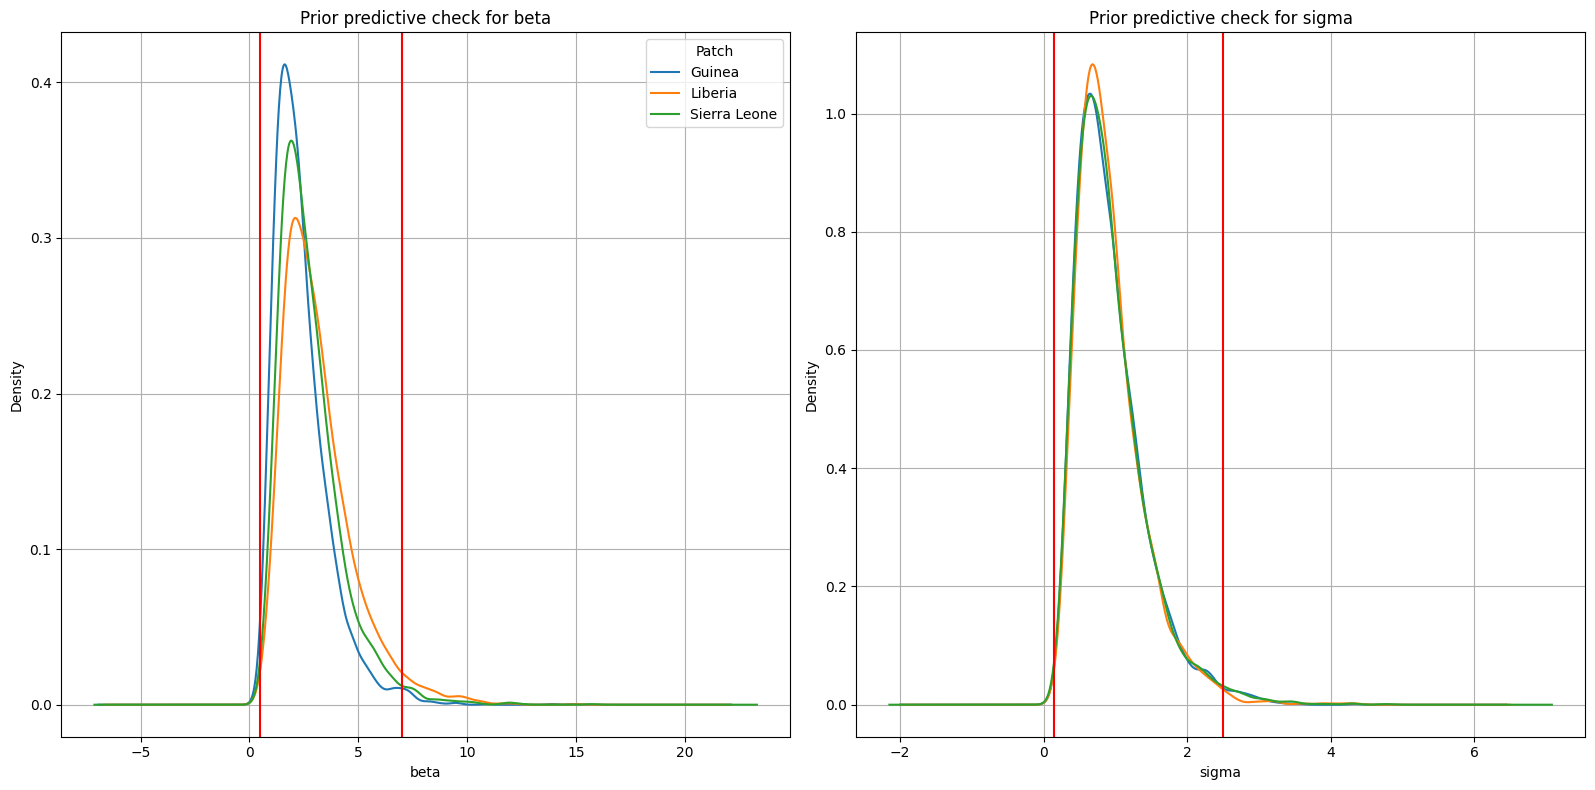

In [ ]:
params = ['beta','sigma']
boundaries = [0.5, 7, 0.14, 2.5]

# 5 parameters → grid of 2×3 (since ncols=3)
fig, axes = plot_prior(prior_check, params, boundary = boundaries, ncols=3)
plt.show()

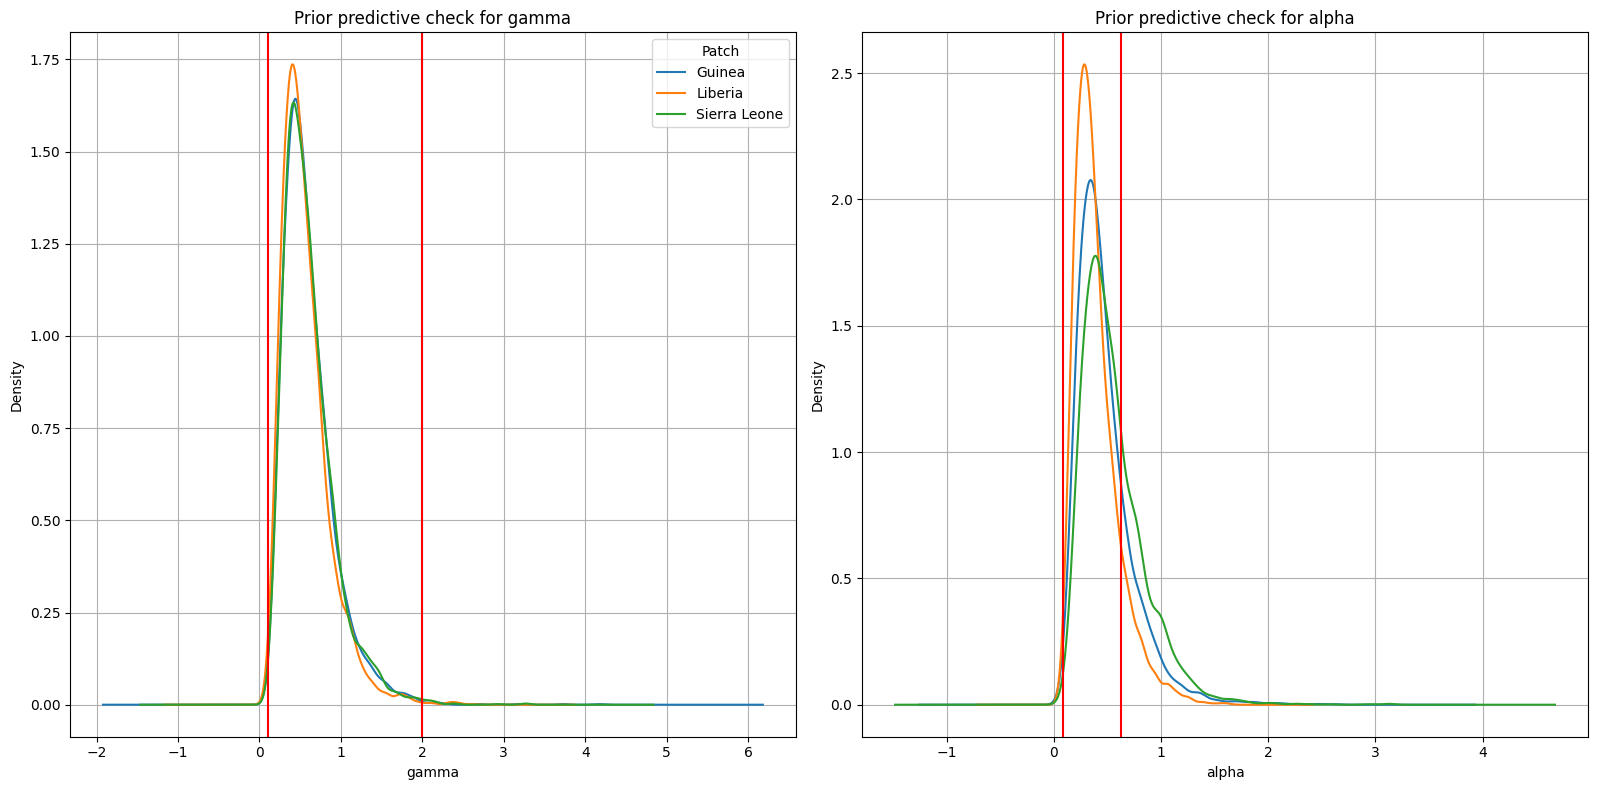

In [ ]:
params = ['gamma', 'alpha']
boundaries = [0.1, 2.0, 0.09, 0.63]

# 5 parameters → grid of 2×3 (since ncols=3)
fig, axes = plot_prior(prior_check, params, boundary = boundaries, ncols=3)
plt.show()

In [ ]:
# infection_draws = prior_check.draws_pd("y")
# lines = plt.plot(range(1,15),
#                  infection_draws,
#                  color = "k", alpha = 0.1)
# plt.axhline(y=N[0], color='r', linestyle='--')
# plt.xlabel('Time')
# plt.ylabel('Number of infections')
# plt.show()

# R0

from sympy import *
init_printing()